# K-Means Clustering pada Data Polutan Udara: Implementasi Python dan KNIME

Catatan ini adalah **bagian 2 dari 2** analisis data polutan udara. Data yang dipakai adalah hasil ekstraksi 68 fitur TSFEL untuk tiga polutan (**NO2, SO2, CO**) yang digabung menjadi **204 kolom fitur** per kecamatan (3 polutan × 68 fitur), untuk dua skenario interpolasi (**linier** dan **polynomial**). Data seluruh kelas diambil dari **MySQL**, lalu dikelompokkan dengan **K-Means** menggunakan **Python** dan **KNIME**. Seluruh daerah yang tercatat di basis data diikutkan dalam perhitungan dan dipetakan.

Cakupan catatan ini:
1. Pengambilan data dari MySQL
2. Praproses fitur
3. Reduksi dimensi 203 → 74 → 37
4. Eksperimen jumlah cluster dengan Silhouette Coefficient
5. Analisis jumlah cluster pada PCA 37 komponen dan 68 fitur per polutan
6. Hasil clustering pada tiap dimensi, beserta scatter plot
7. Peta hasil clustering (segmentasi wilayah)
8. Implementasi workflow KNIME
9. Perbandingan hasil dan kesimpulan

## Landasan Singkat

| Istilah | Penjelasan |
|:---|:---|
| **TSFEL** | Pustaka untuk mengekstraksi fitur dari deret waktu (statistik, temporal, dan spektral). Setiap polutan menghasilkan 68 fitur. |
| **Interpolasi linier / polynomial** | Dua cara mengisi data deret waktu yang hilang sebelum ekstraksi fitur. Keduanya menghasilkan dua tabel fitur yang dibandingkan. |
| **Standardisasi (z-score)** | Mengubah tiap fitur menjadi rata-rata 0 dan simpangan baku 1 agar fitur berskala besar tidak mendominasi jarak. |
| **PCA** | *Principal Component Analysis*, yaitu mereduksi dimensi dengan membentuk komponen baru yang mempertahankan variansi data sebanyak mungkin. |
| **K-Means** | Algoritma clustering yang membagi data ke dalam *K* kelompok berdasarkan kedekatan terhadap pusat kelompok (centroid). |
| **Silhouette Coefficient** | Ukuran kualitas cluster pada rentang −1 sampai 1. Nilai mendekati 1 berarti anggota cluster rapat dan terpisah baik dari cluster lain; nilai mendekati 0 berarti cluster saling tumpang tindih. |

Sebagai acuan interpretasi (Kaufman dan Rousseeuw, 1990): nilai di atas 0,70 menunjukkan struktur cluster kuat, 0,51 sampai 0,70 struktur wajar, 0,26 sampai 0,50 struktur lemah, dan di bawah 0,25 praktis tidak ada struktur cluster.

**Alur analisis:** data MySQL → standardisasi (tanpa membuang fitur) → reduksi dimensi (203, 74, 37) → K-Means dengan K = 2 sampai 10 → pemilihan K terbaik berdasarkan Silhouette Coefficient → scatter plot dan peta segmentasi wilayah → pembandingan dengan workflow KNIME.

## 1. Pengambilan Data dari Database MySQL

Data seluruh kelas berada pada dua tabel MySQL: `ekstraksi_fitur_linear` dan `ekstraksi_fitur_polynomial`. Kredensial disimpan di **Colab Secrets** (`AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`, `AIVEN_USER`, `AIVEN_PASSWORD`) agar tidak tertulis di kode.

In [131]:
!pip install -q pandas sqlalchemy pymysql scikit-learn folium geopy seaborn contextily

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [133]:
from google.colab import userdata
from sqlalchemy.engine import URL

AIVEN_HOST = userdata.get("AIVEN_HOST")
AIVEN_PORT = int(userdata.get("AIVEN_PORT"))
AIVEN_DB = userdata.get("AIVEN_DB")
AIVEN_USER = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")

# URL.create meng-encode karakter khusus pada password (mis. '#', '@') secara otomatis
db_url = URL.create(
    drivername="mysql+pymysql",
    username=AIVEN_USER,
    password=AIVEN_PASSWORD,
    host=AIVEN_HOST,
    port=AIVEN_PORT,
    database=AIVEN_DB,
)

engine = create_engine(db_url)

print("Koneksi Aiven siap digunakan.")

Koneksi Aiven siap digunakan.


In [134]:
# Daftar skenario interpolasi dan tabel sumbernya (kunci dipakai di seluruh notebook)
SKENARIO = ["linear", "polynomial"]
NAMA_TABEL = {
    "linear": "ekstraksi_fitur_linear",
    "polynomial": "ekstraksi_fitur_polynomial",
}

data_mentah = {}
sumber_data = "MySQL (Aiven)"

for sk, nama_tabel in NAMA_TABEL.items():
    try:
        data_mentah[sk] = pd.read_sql(f"SELECT * FROM `{nama_tabel}`", engine)
    except Exception as e:
        # Cadangan: bila koneksi gagal, pakai CSV dengan nama tabel yang sama
        print(f"Gagal membaca '{nama_tabel}' dari MySQL ({repr(e)[:100]}). Mencoba {nama_tabel}.csv ...")
        data_mentah[sk] = pd.read_csv(f"{nama_tabel}.csv")
        sumber_data = "berkas CSV"

    df = data_mentah[sk]
    ganda = int(df["nama"].duplicated().sum()) if "nama" in df.columns else "-"
    print(f"{nama_tabel} ({sk}): ukuran data = {df.shape}, jumlah nama ganda = {ganda}")

ekstraksi_fitur_linear (linear): ukuran data = (37, 207), jumlah nama ganda = 0
ekstraksi_fitur_polynomial (polynomial): ukuran data = (37, 207), jumlah nama ganda = 0


**Contoh data skenario linier**

In [135]:
display(data_mentah["linear"].iloc[:, :8].head())

,id,nama,daerah,no2_abs_energy,no2_auc,no2_autocorr,no2_average_power,no2_calc_centroid
0,1,Muhammad Ali Murtadho,Baron Nganjuk,3.327524e-07,0.010370,17.0,9.116503e-10,203.671392
1,2,Ainur Raftuzzaki,Nunukan,1.562548e-08,0.001696,3.0,6.510616e-11,124.455523
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",2.437783e-07,0.008625,9.0,6.752861e-10,163.948262
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",2.219284e-06,0.025450,6.0,6.096933e-09,192.029475
4,10,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",4.397654e-06,0.048498,2.0,7.569111e-09,325.789743


**Contoh data skenario polynomial**

In [136]:
display(data_mentah["polynomial"].iloc[:, :8].head())

,id,nama,daerah,no2_abs_energy,no2_auc,no2_autocorr,no2_average_power,no2_calc_centroid
0,1,Muhammad Ali Murtadho,Baron Nganjuk,3.327524e-07,0.010370,17.0,9.116503e-10,203.671392
1,2,Ainur Raftuzzaki,Nunukan,1.718086e-08,0.001736,2.0,7.158691e-11,124.290205
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",3.913332e-07,0.009838,12.0,1.084025e-09,130.808445
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",2.432000e-06,0.026015,6.0,6.681318e-09,196.790603
4,9,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",4.409992e-06,0.048503,2.0,7.590347e-09,325.271345


Penjelasan kode di atas adalah sebagai berikut.

- Kredensial dibaca dari Colab Secrets, dan koneksi dibuat dengan `URL.create` serta driver `pymysql` (aman untuk password berkarakter khusus seperti `#`).
- `SKENARIO` dan `NAMA_TABEL` mendefinisikan kunci `"linear"` dan `"polynomial"` yang dipakai di seluruh notebook; kedua tabel dibaca ke dictionary `data_mentah`.
- Bila koneksi gagal, dipakai CSV dengan nama tabel yang sama dan `sumber_data` berubah menjadi "berkas CSV".
- Keluaran menampilkan jumlah baris (kecamatan), jumlah kolom (3 kolom identitas + 204 fitur = 207), dan jumlah nama ganda.

## 2. Persiapan Fitur

Kolom `id`, `nama`, dan `daerah` dipisahkan dari fitur. **Tidak ada kolom fitur yang dibuang**, sehingga kedua skenario (linier dan polynomial) memakai himpunan fitur yang sama, yaitu **204 fitur** (3 polutan × 68 fitur TSFEL), dan perhitungannya setara. Langkah yang dilakukan hanya:

1. konversi ke numerik,
2. standardisasi z-score dengan `StandardScaler` agar fitur berskala besar tidak mendominasi jarak (kolom konstan otomatis bernilai 0 dan tidak memengaruhi jarak),
3. pengaman teknis: bila ada sel `inf`/`NaN`, diisi median kolom (atau 0 bila seluruh kolom kosong) karena K-Means tidak dapat memproses `NaN`. Jumlah sel yang diisi dilaporkan di tabel ringkasan.

In [137]:
from sklearn.preprocessing import StandardScaler

KOLOM_IDENTITAS = ["id", "nama", "daerah"]

def siapkan_fitur(df):
    """Memisahkan identitas dan fitur TANPA membuang kolom apa pun."""
    ada = [c for c in KOLOM_IDENTITAS if c in df.columns]
    ident = df[ada].reset_index(drop=True)
    X = df.drop(columns=ada).apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
    X = X.replace([np.inf, -np.inf], np.nan)

    n_awal = X.shape[1]
    n_nan_terisi = int(X.isna().sum().sum())
    if n_nan_terisi:                       # pengaman teknis: K-Means tidak menerima NaN
        X = X.fillna(X.median()).fillna(0)
    n_konstan = int((X.nunique() <= 1).sum())   # hanya dilaporkan, TIDAK dibuang

    laporan = {"kolom_awal": n_awal, "sel_nan_diisi": n_nan_terisi,
               "kolom_konstan_(dipertahankan)": n_konstan, "kolom_dibuang": 0, "kolom_akhir": X.shape[1]}
    return ident, X, laporan, []

ident, X_fitur, X_scaled, laporan_praproses, kolom_dibuang = {}, {}, {}, {}, {}
for sk in SKENARIO:
    ident[sk], X_fitur[sk], laporan_praproses[sk], kolom_dibuang[sk] = siapkan_fitur(data_mentah[sk])
    X_scaled[sk] = StandardScaler().fit_transform(X_fitur[sk].values)

**Ringkasan praproses**

In [138]:
display(pd.DataFrame(laporan_praproses).T)

,kolom_awal,sel_nan_diisi,kolom_konstan_(dipertahankan),kolom_dibuang,kolom_akhir
linear,204,0,6,0,204
polynomial,204,0,5,0,204


**Kolom yang dibuang**

In [139]:
for sk in SKENARIO:
    print(f"[{sk}] kolom yang dibuang: tidak ada | jumlah fitur dipakai = {X_scaled[sk].shape[1]}")

# Kedua skenario harus memakai himpunan fitur yang sama
sama_kolom = list(X_fitur["linear"].columns) == list(X_fitur["polynomial"].columns)
print("\nNama kolom fitur linier dan polynomial sama:", sama_kolom)

[linear] kolom yang dibuang: tidak ada | jumlah fitur dipakai = 204
[polynomial] kolom yang dibuang: tidak ada | jumlah fitur dipakai = 204

Nama kolom fitur linier dan polynomial sama: True


**Pemeriksaan data**

In [140]:
# Kolom id dapat berbeda antar tabel, sehingga kesamaan data diperiksa lewat nama dan daerah
kunci = ["nama", "daerah"]
a = ident["linear"][kunci].reset_index(drop=True)
b = ident["polynomial"][kunci].reset_index(drop=True)
if a.equals(b):
    print("Urutan kecamatan pada tabel linier dan polynomial sama.")
elif set(map(tuple, a.values)) == set(map(tuple, b.values)):
    print("Himpunan kecamatan sama, hanya urutan baris berbeda (tidak masalah: tiap skenario di-cluster dan dipetakan dengan identitasnya sendiri).")
else:
    print("PERINGATAN: isi nama/daerah pada tabel linier dan polynomial berbeda - periksa data.")

N_SAMPEL = X_scaled["linear"].shape[0]
print(f"\nJumlah sampel (kecamatan): {N_SAMPEL}")
print(f"Jumlah fitur: linier = {X_scaled['linear'].shape[1]}, polynomial = {X_scaled['polynomial'].shape[1]}")

PERINGATAN: isi nama/daerah pada tabel linier dan polynomial berbeda - periksa data.

Jumlah sampel (kecamatan): 37
Jumlah fitur: linier = 204, polynomial = 204


Penjelasan kode di atas adalah sebagai berikut.

- `siapkan_fitur()` hanya memisahkan identitas dari fitur dan mengonversi ke numerik; **tidak ada kolom yang dibuang**, sehingga linier dan polynomial sama-sama 204 fitur.
- Standardisasi dilakukan per skenario. Kolom konstan menjadi nol setelah standardisasi, sehingga tidak berpengaruh pada jarak.
- `N_SAMPEL` menentukan batas jumlah komponen PCA.

## 3. Reduksi Dimensi: 203 → 74 → 37

Clustering dibandingkan pada tiga target dimensi, yaitu **203**, **74**, dan **37**, seluruhnya melalui PCA dari 204 fitur awal (tanpa pembuangan fitur). PCA menghasilkan paling banyak min(jumlah sampel, jumlah fitur) komponen, sehingga bila sampel hanya 37 maka target 203 dan 74 dibatasi menjadi 37 komponen dan hasilnya identik dengan dimensi 37. Dengan demikian 203, 74, dan 37 merupakan target dimensi PCA, bukan jumlah fitur terpilih. Dimensi efektif yang dipakai dicatat pada tabel di bawah.

In [141]:
from sklearn.decomposition import PCA

# Target reduksi dimensi dari 204 fitur awal: 203 -> 74 -> 37
assert X_scaled["linear"].shape[1] == X_scaled["polynomial"].shape[1], "Jumlah fitur linier dan polynomial harus sama"
DIMENSI_TARGET = [203, 74, 37]

def reduksi(Xs, target):
    n, p = Xs.shape
    if target >= p:
        return Xs, p, "tanpa PCA", 1.0
    n_komp = min(target, n, p)
    pca = PCA(n_components=n_komp, random_state=42)
    Z = pca.fit_transform(Xs)
    return Z, n_komp, f"PCA {n_komp}", float(pca.explained_variance_ratio_.sum())

representasi = {sk: {} for sk in SKENARIO}
baris = []
for sk in SKENARIO:
    for target in DIMENSI_TARGET:
        Z, d_eff, ket, var_exp = reduksi(X_scaled[sk], target)
        representasi[sk][target] = {"Z": Z, "dimensi_efektif": d_eff, "keterangan": ket}
        baris.append({"skenario": sk, "dimensi_target": target, "dimensi_efektif": d_eff,
                      "metode": ket, "variansi_terjelaskan": round(var_exp, 4)})
tabel_dimensi = pd.DataFrame(baris)

In [142]:
display(tabel_dimensi)

sama = tabel_dimensi.groupby("skenario")["dimensi_efektif"].nunique()
for sk, n_unik in sama.items():
    if n_unik < len(DIMENSI_TARGET):
        print(f"Catatan [{sk}]: beberapa dimensi target menghasilkan dimensi efektif yang sama "
              f"(dibatasi jumlah sampel = {N_SAMPEL}), sehingga hasil clustering-nya identik.")

,skenario,dimensi_target,dimensi_efektif,metode,variansi_terjelaskan
0,linear,203,37,PCA 37,1.0
1,linear,74,37,PCA 37,1.0
2,linear,37,37,PCA 37,1.0
3,polynomial,203,37,PCA 37,1.0
4,polynomial,74,37,PCA 37,1.0
5,polynomial,37,37,PCA 37,1.0


Catatan [linear]: beberapa dimensi target menghasilkan dimensi efektif yang sama (dibatasi jumlah sampel = 37), sehingga hasil clustering-nya identik.
Catatan [polynomial]: beberapa dimensi target menghasilkan dimensi efektif yang sama (dibatasi jumlah sampel = 37), sehingga hasil clustering-nya identik.


Penjelasan kode di atas adalah sebagai berikut.


- `reduksi()` menjalankan `PCA(n_components=min(target, sampel, fitur))`; target 203 dan 74 dibatasi menjadi 37 komponen karena hanya ada 37 sampel. Data dipakai penuh tanpa PCA hanya bila target sama dengan atau melebihi jumlah fitur.
- Tabel `tabel_dimensi` memuat dimensi efektif, metode, dan variansi yang dijelaskan tiap kombinasi.

## 4. Eksperimen Jumlah Cluster dengan Silhouette Coefficient

Diuji seluruh kombinasi skenario (linier, polynomial) × dimensi (203, 74, 37) × K = 2 sampai 10 dengan K-Means (`random_state=42`, `n_init=10`). Kualitas diukur dengan Silhouette Coefficient rata-rata. Ukuran cluster terkecil (`min_anggota`) turut dicatat karena cluster beranggota tunggal dapat menaikkan skor akibat satu outlier.

In [143]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

K_RANGE = list(range(2, 11))
MIN_ANGGOTA = 1      # ubah ke 2 bila cluster beranggota tunggal (outlier) tidak ingin dianggap solusi valid

baris, label_store = [], {}
for sk in SKENARIO:
    for target in DIMENSI_TARGET:
        Z = representasi[sk][target]["Z"]
        d_eff = representasi[sk][target]["dimensi_efektif"]
        for k in K_RANGE:
            if k >= Z.shape[0]:
                continue
            lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Z)
            if len(set(lab)) < 2:
                continue
            ukuran = np.bincount(lab)
            baris.append({"skenario": sk, "dimensi_target": target, "dimensi_efektif": d_eff, "K": k,
                          "silhouette": silhouette_score(Z, lab), "min_anggota": int(ukuran.min()),
                          "ukuran_cluster": ukuran.tolist()})
            label_store[(sk, target, k)] = lab

hasil_eksperimen = pd.DataFrame(baris)
kandidat = hasil_eksperimen[hasil_eksperimen["min_anggota"] >= MIN_ANGGOTA]

if kandidat.empty:
    raise ValueError("Tidak ada solusi dengan min_anggota >= MIN_ANGGOTA. Turunkan nilai MIN_ANGGOTA.")

# Urutkan: silhouette tertinggi dulu; bila seri (selisih < 1e-8) pilih dimensi efektif terkecil, lalu dimensi target terkecil, lalu K terkecil
kandidat = kandidat.assign(sil_bulat=kandidat["silhouette"].round(8)).sort_values(
    ["sil_bulat", "dimensi_efektif", "dimensi_target", "K"], ascending=[False, True, True, True])
urut = dict(by=["skenario", "dimensi_target"], ascending=[True, False])
terbaik_kombinasi = kandidat.groupby(["skenario", "dimensi_target"]).head(1).sort_values(**urut).drop(columns="sil_bulat").reset_index(drop=True)
terbaik_skenario = kandidat.groupby("skenario").head(1).sort_values("skenario").drop(columns="sil_bulat").reset_index(drop=True)
terbaik_global = kandidat.iloc[0].drop(labels="sil_bulat")

**K terbaik untuk setiap kombinasi skenario × dimensi**

In [144]:
print("K terbaik berdasarkan Silhouette Coefficient tertinggi:")
display(terbaik_kombinasi)

K terbaik berdasarkan Silhouette Coefficient tertinggi:


,skenario,dimensi_target,dimensi_efektif,K,silhouette,min_anggota,ukuran_cluster
0,linear,203,37,2,0.490860,3,"[34, 3]"
1,linear,74,37,2,0.490860,3,"[34, 3]"
2,linear,37,37,2,0.490860,3,"[34, 3]"
3,polynomial,203,37,2,0.537546,2,"[35, 2]"
4,polynomial,74,37,2,0.537546,2,"[35, 2]"
5,polynomial,37,37,2,0.537546,2,"[35, 2]"


**Kombinasi terbaik per skenario**

In [145]:
display(terbaik_skenario)

,skenario,dimensi_target,dimensi_efektif,K,silhouette,min_anggota,ukuran_cluster
0,linear,37,37,2,0.490860,3,"[34, 3]"
1,polynomial,37,37,2,0.537546,2,"[35, 2]"


**Kombinasi terbaik keseluruhan**

In [146]:
print(f"Kombinasi terbaik keseluruhan: skenario = {terbaik_global['skenario']}, "
      f"dimensi = {int(terbaik_global['dimensi_target'])} (efektif {int(terbaik_global['dimensi_efektif'])}), "
      f"K = {int(terbaik_global['K'])}, silhouette = {terbaik_global['silhouette']:.4f}")
if terbaik_global["min_anggota"] < 2:
    print("PERHATIAN: solusi terbaik memiliki cluster beranggota tunggal (kemungkinan outlier). "
          "Bandingkan dengan MIN_ANGGOTA = 2 sebelum menarik kesimpulan.")

Kombinasi terbaik keseluruhan: skenario = polynomial, dimensi = 37 (efektif 37), K = 2, silhouette = 0.5375


Penjelasan kode di atas adalah sebagai berikut.


- Perulangan skenario → dimensi → K mencatat Silhouette, dimensi efektif, dan ukuran cluster ke `hasil_eksperimen`; label disimpan di `label_store`.
- Solusi terbaik dipilih per kombinasi skenario × dimensi, per skenario, dan secara keseluruhan; bila skor seri dipilih dimensi dan K yang lebih kecil.
- `MIN_ANGGOTA` mengatur apakah cluster beranggota tunggal dianggap valid, dan sel memberi peringatan bila pemenangnya memilikinya.

**Kurva Silhouette Coefficient terhadap K**

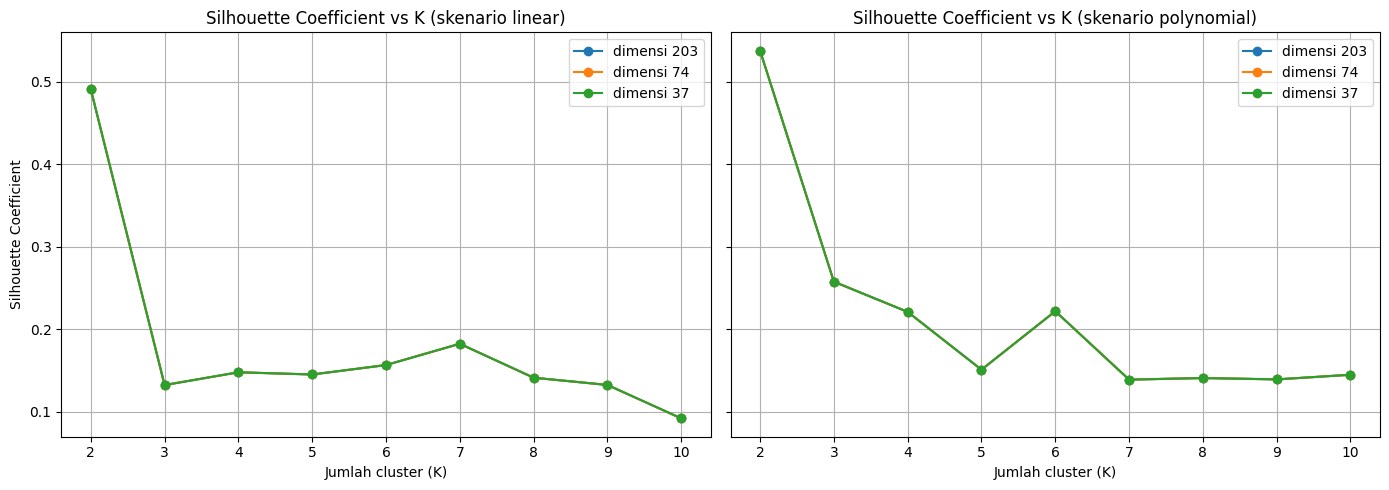

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Kurva Silhouette terhadap K untuk tiap dimensi, per skenario
fig, axes = plt.subplots(1, len(SKENARIO), figsize=(14, 5), sharey=True)
for ax, sk in zip(axes, SKENARIO):
    for target in DIMENSI_TARGET:
        d = hasil_eksperimen[(hasil_eksperimen["skenario"] == sk) & (hasil_eksperimen["dimensi_target"] == target)]
        ax.plot(d["K"], d["silhouette"], marker="o", label=f"dimensi {target}")
    ax.set_title(f"Silhouette Coefficient vs K (skenario {sk})")
    ax.set_xlabel("Jumlah cluster (K)")
    ax.grid(True)
    ax.legend()
axes[0].set_ylabel("Silhouette Coefficient")
plt.tight_layout()
plt.show()

**Heatmap Silhouette Coefficient (K × dimensi)**

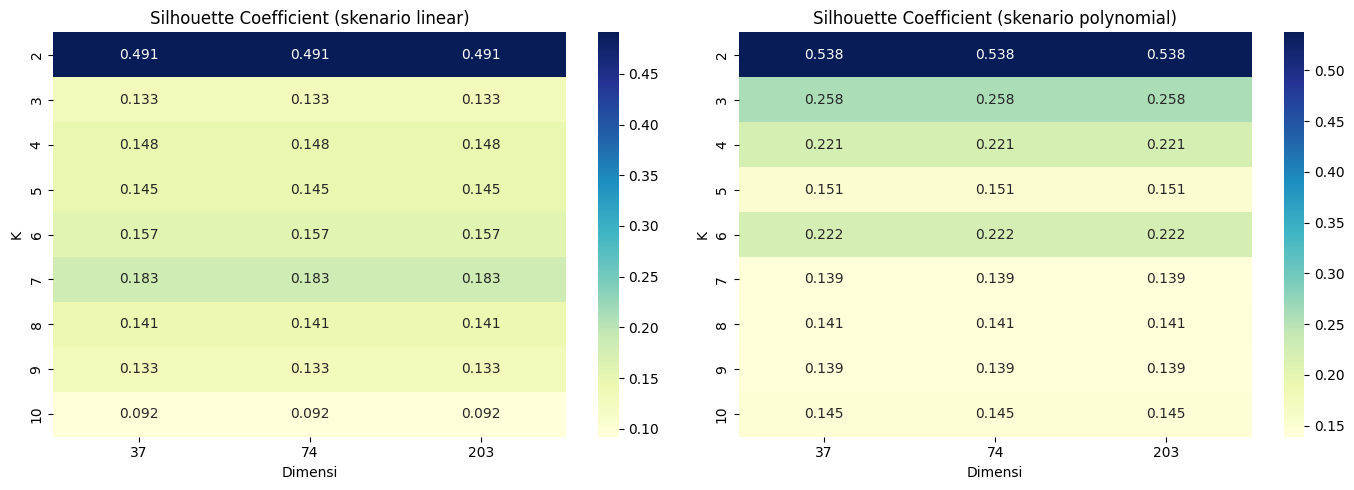

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2) Heatmap K x dimensi, per skenario
fig, axes = plt.subplots(1, len(SKENARIO), figsize=(14, 5))
for ax, sk in zip(axes, SKENARIO):
    tabel = hasil_eksperimen[hasil_eksperimen["skenario"] == sk].pivot(index="K", columns="dimensi_target", values="silhouette")
    sns.heatmap(tabel, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"Silhouette Coefficient (skenario {sk})")
    ax.set_xlabel("Dimensi")
plt.tight_layout()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.


- Grafik garis menunjukkan Silhouette terhadap K pada tiap dimensi, dan heatmap merangkumnya dalam matriks K × dimensi.
- Garis dimensi 74 dan 37 berimpit bila dimensi efektifnya sama (lihat bagian 3).

**Interpretasi hasil eksperimen.** (Baca bersama tabel dan grafik di atas; angka dihasilkan oleh sel di atas.)

- Perhatikan K dengan Silhouette Coefficient tertinggi pada tiap skenario dan dimensi di tabel *K terbaik*, lalu nilainya dibandingkan dengan skala Kaufman dan Rousseeuw (di atas 0,70 kuat, 0,51 sampai 0,70 wajar, 0,26 sampai 0,50 lemah, di bawah 0,25 tidak berstruktur).
- Bila skor identik pada dimensi 203, 74, dan 37, penyebabnya adalah data hanya berisi 37 kecamatan sehingga ruang fitur yang benar-benar terpakai paling banyak 36 dimensi. PCA dengan 37 komponen hanya memutar sumbu tanpa mengubah jarak antar titik (variansi terjelaskan 100%), sehingga reduksi dimensi tidak mengubah hasil clustering.
- Periksa kolom `ukuran_cluster` pada tabel. Bila ada cluster yang hanya berisi 1 sampai 3 kecamatan, skor silhouette lebih mencerminkan pemisahan kecamatan ekstrem (outlier) daripada dua segmen wilayah yang seimbang.

## 5. Analisis Jumlah Cluster pada PCA 37 Komponen dan 68 Fitur per Polutan

Bagian ini menjawab tiga pertanyaan: (1) berapa jumlah cluster (K) terbaik, (2) bagaimana kualitas cluster bila jumlah komponen PCA divariasikan dari 1 sampai 37, dan (3) seberapa baik data terkelompok. Prosedur yang sama dijalankan pada dua jenis data:

1. **Data gabungan** tiga polutan (NO2, SO2, CO), yaitu seluruh 204 fitur pada bagian 2.
2. **68 fitur per polutan**, yaitu fitur TSFEL milik NO2, SO2, dan CO dianalisis sendiri-sendiri (seluruh 68 fitur tiap polutan dipertahankan).

Langkah untuk setiap data: (a) standardisasi, (b) reduksi PCA menjadi 37 komponen, yaitu jumlah maksimum yang mungkin karena hanya ada 37 kecamatan, (c) K-Means untuk K = 2 sampai 10 dengan *Elbow Method* (inertia) dan Silhouette Coefficient, (d) penyapuan jumlah komponen PCA dari 1 sampai 37, dan (e) pembandingan dengan data tanpa PCA.

In [149]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE_AN = list(range(2, 11))
N_KOMP_MAX = 37
POLUTAN = ["no2", "so2", "co"]
NAMA_DATA = ["gabungan"] + POLUTAN

def kategori_silhouette(s):
    """Skala Kaufman dan Rousseeuw (1990)."""
    if s > 0.70: return "kuat"
    if s > 0.50: return "wajar"
    if s > 0.25: return "lemah"
    return "tidak berstruktur"

def evaluasi_k(Z):
    """K-Means untuk K = 2..10; mengembalikan inertia, silhouette, dan ukuran cluster tiap K."""
    baris = []
    for k in K_RANGE_AN:
        if k >= Z.shape[0]:
            continue
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(Z)
        if len(set(lab)) < 2:
            continue
        ukuran = np.bincount(lab)
        baris.append({"K": k, "inertia": km.inertia_, "silhouette": silhouette_score(Z, lab),
                      "min_anggota": int(ukuran.min()), "ukuran_cluster": ukuran.tolist()})
    return pd.DataFrame(baris)

def sapu_pca(Xs):
    """Untuk tiap jumlah komponen PCA 1..37, catat K dan silhouette terbaik."""
    baris = []
    for n in range(1, min(N_KOMP_MAX, Xs.shape[0], Xs.shape[1]) + 1):
        Z = PCA(n_components=n, random_state=42).fit_transform(Xs)
        e = evaluasi_k(Z)
        t = e.loc[e["silhouette"].idxmax()]
        baris.append({"n_komponen": n, "K_terbaik": int(t["K"]), "silhouette_terbaik": float(t["silhouette"])})
    return pd.DataFrame(baris)

def matriks_data(nama, sk):
    """Matriks fitur terstandardisasi: data gabungan, atau fitur milik satu polutan."""
    if nama == "gabungan":
        return X_scaled[sk]
    kolom = [c for c in X_fitur[sk].columns if c.startswith(f"{nama}_")]
    return StandardScaler().fit_transform(X_fitur[sk][kolom].values)

def analisis_data(Xs):
    n_komp = min(N_KOMP_MAX, Xs.shape[0], Xs.shape[1])
    Z37 = PCA(n_components=n_komp, random_state=42).fit_transform(Xs)
    return {"n_fitur": Xs.shape[1], "n_komp": n_komp, "eval_pca": evaluasi_k(Z37),
            "eval_tanpa_pca": evaluasi_k(Xs), "sapuan": sapu_pca(Xs)}

In [150]:
# Perhitungan seluruh data x skenario (proses sekitar 1-2 menit; tidak menampilkan keluaran)
hasil_analisis = {}
for nama in NAMA_DATA:
    for sk in SKENARIO:
        hasil_analisis[(nama, sk)] = analisis_data(matriks_data(nama, sk))
print(f"Analisis selesai: {len(hasil_analisis)} kombinasi data x skenario.")

Analisis selesai: 8 kombinasi data x skenario.


In [151]:
def tabel_evaluasi(nama, sk):
    e = hasil_analisis[(nama, sk)]["eval_pca"].copy()
    e["terbaik"] = np.where(e["silhouette"] == e["silhouette"].max(), "<-- K terbaik", "")
    e["inertia"] = e["inertia"].round(2)
    e["silhouette"] = e["silhouette"].round(4)
    print(f"{nama.upper()} | interpolasi {sk} | {hasil_analisis[(nama, sk)]['n_fitur']} fitur -> PCA {hasil_analisis[(nama, sk)]['n_komp']} komponen")
    display(e)

def plot_evaluasi(nama_list, sk, judul):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for nama in nama_list:
        e = hasil_analisis[(nama, sk)]["eval_pca"]
        axes[0].plot(e["K"], e["inertia"], marker="o", linestyle="--", label=nama.upper())
        axes[1].plot(e["K"], e["silhouette"], marker="o", label=nama.upper())
        if len(nama_list) == 1:
            kb = int(e.loc[e["silhouette"].idxmax(), "K"])
            axes[1].axvline(kb, color="red", linestyle=":", label=f"K terbaik = {kb}")
    axes[0].set_title("Elbow Method (inertia)")
    axes[0].set_ylabel("Inertia")
    axes[1].set_title("Silhouette Coefficient")
    axes[1].set_ylabel("Silhouette Coefficient")
    if len(nama_list) > 1:
        axes[0].set_yscale("log")
    for ax in axes:
        ax.set_xlabel("Jumlah cluster (K)")
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.suptitle(judul, fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_sapuan(nama_list, sk, judul):
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for nama in nama_list:
        s = hasil_analisis[(nama, sk)]["sapuan"]
        ax.plot(s["n_komponen"], s["silhouette_terbaik"], marker=".", label=nama.upper())
    ax.set_title(judul)
    ax.set_xlabel("Jumlah komponen PCA")
    ax.set_ylabel("Silhouette Coefficient terbaik (K = 2..10)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def tabel_sapuan(nama_list, sk, titik=(1, 2, 3, 5, 10, 15, 20, 25, 30, 37)):
    gabung = None
    for nama in nama_list:
        s = hasil_analisis[(nama, sk)]["sapuan"]
        s = s[s["n_komponen"].isin(titik)].set_index("n_komponen")
        s = s.rename(columns={"K_terbaik": f"K_{nama}", "silhouette_terbaik": f"sil_{nama}"})
        s[f"sil_{nama}"] = s[f"sil_{nama}"].round(4)
        gabung = s if gabung is None else gabung.join(s)
    display(gabung)

### 5.1 Data Gabungan (3 Polutan): PCA 37 Komponen

**Evaluasi K - interpolasi linier**

In [152]:
tabel_evaluasi("gabungan", "linear")

GABUNGAN | interpolasi linear | 204 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,5442.27,0.4909,3,"[34, 3]",<-- K terbaik
1,3,4835.84,0.1326,1,"[20, 1, 16]",
2,4,3726.48,0.1481,1,"[3, 18, 15, 1]",
3,5,3454.30,0.1454,1,"[13, 21, 1, 1, 1]",
4,6,2898.60,0.1568,1,"[13, 20, 1, 1, 1, 1]",
5,7,2498.57,0.1826,1,"[22, 4, 1, 1, 7, 1, 1]",
6,8,2148.52,0.1415,1,"[2, 10, 1, 18, 3, 1, 1, 1]",
7,9,1907.21,0.1327,1,"[14, 1, 1, 1, 3, 1, 13, 2, 1]",
8,10,1728.20,0.0923,1,"[1, 12, 1, 6, 1, 9, 1, 3, 1, 2]",


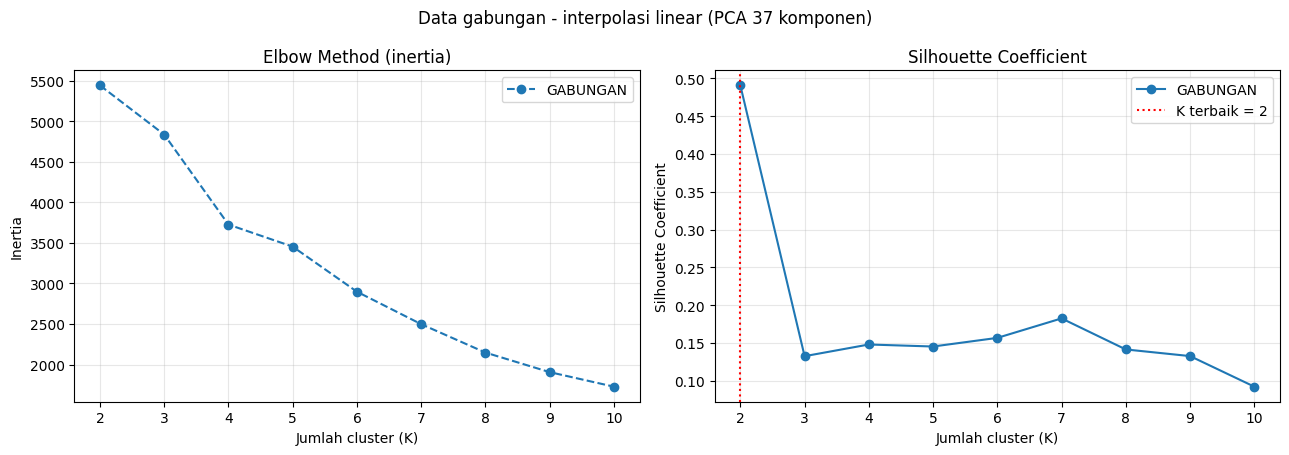

In [153]:
plot_evaluasi(["gabungan"], "linear", "Data gabungan - interpolasi linear (PCA 37 komponen)")

**Evaluasi K - interpolasi polynomial**

In [154]:
tabel_evaluasi("gabungan", "polynomial")

GABUNGAN | interpolasi polynomial | 204 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,5450.82,0.5375,2,"[35, 2]",<-- K terbaik
1,3,4392.71,0.2578,2,"[2, 9, 26]",
2,4,3603.16,0.2212,1,"[2, 25, 9, 1]",
3,5,3252.07,0.1512,1,"[18, 2, 1, 8, 8]",
4,6,2749.89,0.2220,1,"[9, 23, 1, 1, 1, 2]",
5,7,2384.97,0.1392,1,"[9, 1, 9, 1, 14, 1, 2]",
6,8,2091.99,0.1411,1,"[6, 9, 17, 1, 1, 1, 1, 1]",
7,9,1822.79,0.1395,1,"[14, 1, 1, 1, 4, 11, 1, 2, 2]",
8,10,1680.97,0.1451,1,"[3, 14, 1, 1, 1, 1, 8, 6, 1, 1]",


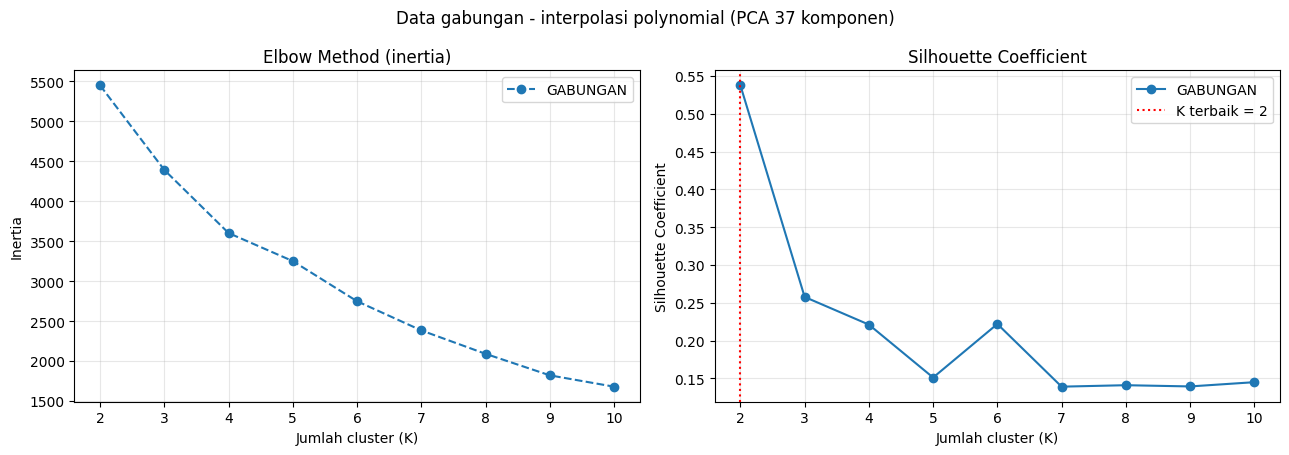

In [155]:
plot_evaluasi(["gabungan"], "polynomial", "Data gabungan - interpolasi polynomial (PCA 37 komponen)")

### 5.2 Kualitas Cluster pada PCA 1 sampai 37 Komponen (Data Gabungan)

**Interpolasi linier**

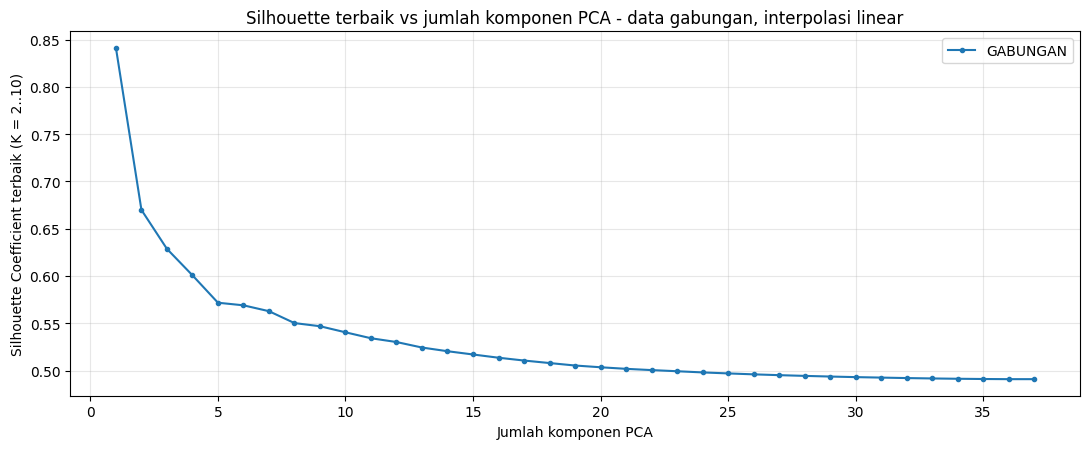

In [156]:
plot_sapuan(["gabungan"], "linear", "Silhouette terbaik vs jumlah komponen PCA - data gabungan, interpolasi linear")

In [157]:
tabel_sapuan(["gabungan"], "linear")

,K_gabungan,sil_gabungan
n_komponen,,
1,2,0.8412
2,2,0.6698
3,3,0.6286
5,2,0.5717
10,2,0.5404
15,2,0.5170
20,2,0.5034
25,2,0.4969
30,2,0.4930


**Interpolasi polynomial**

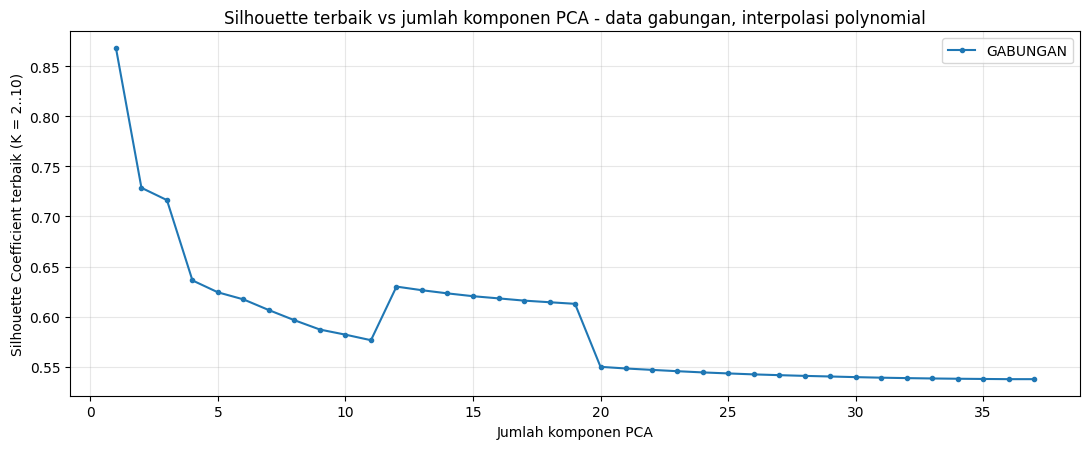

In [158]:
plot_sapuan(["gabungan"], "polynomial", "Silhouette terbaik vs jumlah komponen PCA - data gabungan, interpolasi polynomial")

In [159]:
tabel_sapuan(["gabungan"], "polynomial")

,K_gabungan,sil_gabungan
n_komponen,,
1,2,0.8683
2,2,0.7286
3,2,0.7163
5,2,0.6242
10,2,0.5820
15,2,0.6204
20,2,0.5499
25,2,0.5433
30,2,0.5396


### 5.3 Analisis pada 68 Fitur per Polutan (Prosedur yang Sama)

**Evaluasi K (PCA 37 komponen) - interpolasi linier**

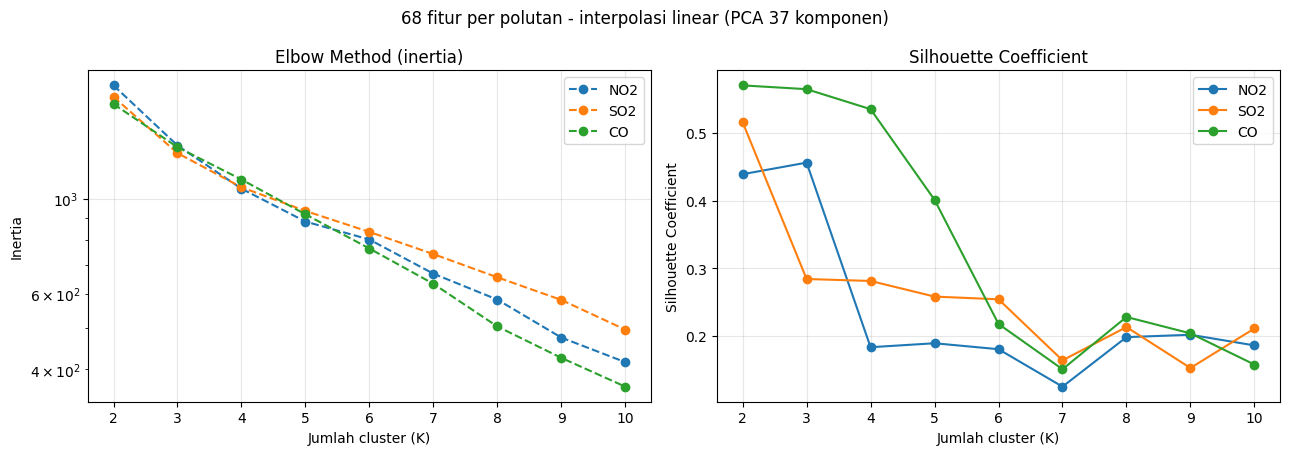

In [160]:
plot_evaluasi(POLUTAN, "linear", "68 fitur per polutan - interpolasi linear (PCA 37 komponen)")

**Evaluasi K (PCA 37 komponen) - interpolasi polynomial**

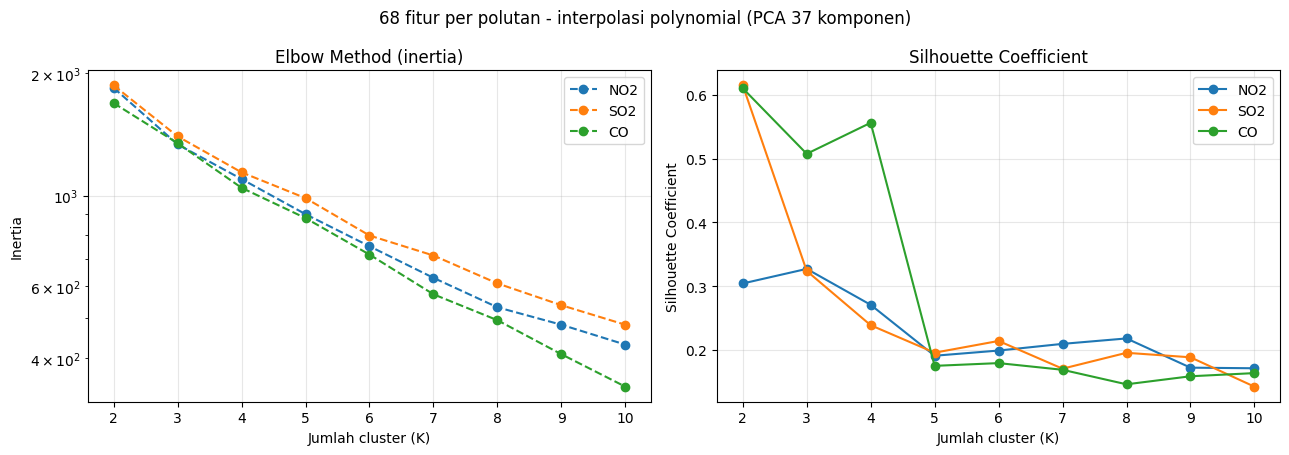

In [161]:
plot_evaluasi(POLUTAN, "polynomial", "68 fitur per polutan - interpolasi polynomial (PCA 37 komponen)")

**Tabel evaluasi K - NO2, interpolasi linier**

In [162]:
tabel_evaluasi("no2", "linear")

NO2 | interpolasi linear | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1835.33,0.4391,4,"[33, 4]",
1,3,1329.24,0.4562,1,"[4, 32, 1]",<-- K terbaik
2,4,1054.37,0.1833,1,"[18, 4, 1, 14]",
3,5,883.76,0.1891,1,"[3, 18, 1, 1, 14]",
4,6,802.32,0.1803,1,"[18, 2, 1, 14, 1, 1]",
5,7,668.09,0.1250,1,"[11, 7, 1, 13, 2, 1, 2]",
6,8,581.22,0.1982,1,"[2, 8, 16, 1, 1, 1, 6, 2]",
7,9,474.10,0.2017,1,"[2, 17, 1, 1, 1, 5, 1, 7, 2]",
8,10,415.45,0.1860,1,"[1, 16, 2, 1, 5, 1, 1, 1, 7, 2]",


**Tabel evaluasi K - NO2, interpolasi polynomial**

In [163]:
tabel_evaluasi("no2", "polynomial")

NO2 | interpolasi polynomial | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1838.82,0.3045,8,"[8, 29]",
1,3,1336.28,0.3273,1,"[8, 28, 1]",<-- K terbaik
2,4,1098.69,0.2710,1,"[26, 9, 1, 1]",
3,5,901.08,0.1912,1,"[7, 15, 1, 1, 13]",
4,6,751.72,0.1993,1,"[8, 15, 1, 2, 1, 10]",
5,7,628.91,0.2098,1,"[2, 15, 10, 1, 1, 6, 2]",
6,8,532.57,0.2183,1,"[1, 8, 11, 2, 1, 11, 1, 2]",
7,9,482.63,0.1725,1,"[1, 11, 1, 2, 11, 5, 3, 2, 1]",
8,10,431.36,0.1716,1,"[4, 7, 2, 13, 2, 1, 1, 1, 1, 5]",


**Tabel evaluasi K - SO2, interpolasi linier**

In [164]:
tabel_evaluasi("so2", "linear")

SO2 | interpolasi linear | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1725.58,0.5159,3,"[34, 3]",<-- K terbaik
1,3,1275.89,0.2841,3,"[13, 21, 3]",
2,4,1062.32,0.2812,1,"[12, 21, 1, 3]",
3,5,935.53,0.2581,1,"[11, 21, 1, 3, 1]",
4,6,835.81,0.2541,1,"[2, 10, 20, 3, 1, 1]",
5,7,742.09,0.1639,1,"[11, 1, 15, 1, 1, 6, 2]",
6,8,655.14,0.2130,1,"[8, 1, 16, 1, 1, 1, 6, 3]",
7,9,580.20,0.1526,1,"[11, 1, 1, 10, 5, 1, 6, 1, 1]",
8,10,494.67,0.2110,1,"[1, 5, 16, 1, 1, 8, 1, 1, 1, 2]",


**Tabel evaluasi K - SO2, interpolasi polynomial**

In [165]:
tabel_evaluasi("so2", "polynomial")

SO2 | interpolasi polynomial | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1864.76,0.6148,1,"[36, 1]",<-- K terbaik
1,3,1398.22,0.3240,2,"[2, 7, 28]",
2,4,1141.21,0.2390,1,"[2, 23, 11, 1]",
3,5,986.55,0.1960,1,"[20, 1, 8, 7, 1]",
4,6,798.77,0.2144,1,"[19, 11, 1, 3, 2, 1]",
5,7,713.49,0.1709,1,"[6, 1, 8, 4, 14, 1, 3]",
6,8,609.46,0.1958,1,"[1, 4, 1, 8, 4, 1, 15, 3]",
7,9,538.85,0.1888,1,"[13, 5, 2, 1, 11, 1, 2, 1, 1]",
8,10,482.58,0.1428,1,"[7, 1, 2, 1, 8, 3, 9, 1, 4, 1]",


**Tabel evaluasi K - CO, interpolasi linier**

In [166]:
tabel_evaluasi("co", "linear")

CO | interpolasi linear | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1660.69,0.5704,3,"[34, 3]",<-- K terbaik
1,3,1317.28,0.5648,1,"[33, 3, 1]",
2,4,1107.45,0.5352,1,"[33, 2, 1, 1]",
3,5,918.63,0.4012,1,"[31, 2, 1, 1, 2]",
4,6,764.72,0.2176,1,"[24, 2, 1, 1, 7, 2]",
5,7,632.75,0.1507,1,"[1, 17, 1, 1, 2, 14, 1]",
6,8,503.19,0.2280,1,"[9, 1, 20, 2, 1, 2, 1, 1]",
7,9,425.12,0.2038,1,"[8, 1, 1, 2, 2, 1, 19, 1, 2]",
8,10,364.29,0.1577,1,"[16, 1, 1, 1, 2, 1, 11, 2, 1, 1]",


**Tabel evaluasi K - CO, interpolasi polynomial**

In [167]:
tabel_evaluasi("co", "polynomial")

CO | interpolasi polynomial | 68 fitur -> PCA 37 komponen


,K,inertia,silhouette,min_anggota,ukuran_cluster,terbaik
0,2,1687.45,0.6103,2,"[2, 35]",<-- K terbaik
1,3,1345.17,0.5076,2,"[3, 2, 32]",
2,4,1045.72,0.5562,1,"[1, 2, 1, 33]",
3,5,881.31,0.1754,1,"[22, 11, 1, 2, 1]",
4,6,717.20,0.1797,1,"[21, 1, 1, 2, 10, 2]",
5,7,573.14,0.1692,1,"[10, 1, 21, 1, 1, 1, 2]",
6,8,495.08,0.1464,1,"[9, 1, 1, 10, 2, 1, 12, 1]",
7,9,408.58,0.1590,1,"[9, 1, 1, 10, 1, 1, 2, 11, 1]",
8,10,340.17,0.1640,1,"[9, 1, 1, 1, 9, 1, 1, 2, 9, 3]",


**PCA 1 sampai 37 komponen - interpolasi linier**

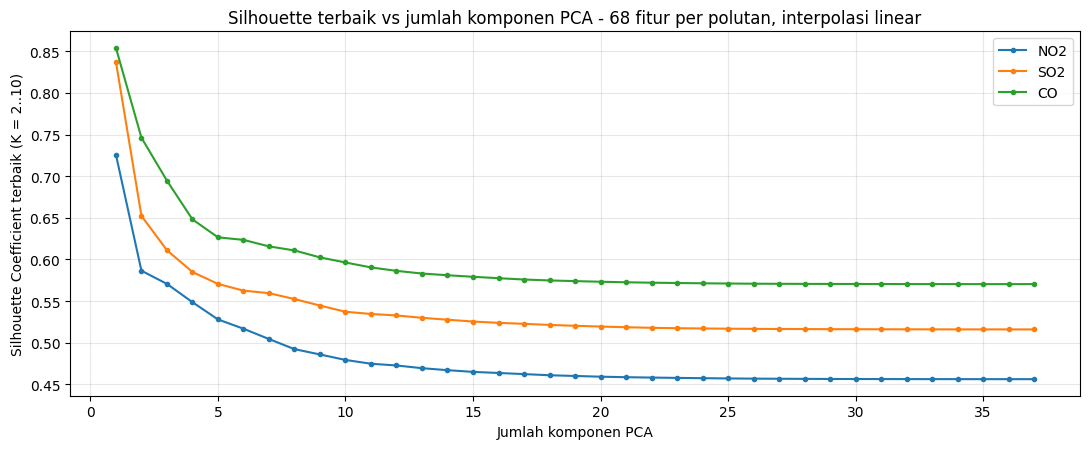

In [168]:
plot_sapuan(POLUTAN, "linear", "Silhouette terbaik vs jumlah komponen PCA - 68 fitur per polutan, interpolasi linear")

In [169]:
tabel_sapuan(POLUTAN, "linear")

,K_no2,sil_no2,K_so2,sil_so2,K_co,sil_co
n_komponen,,,,,,
1,2,0.7258,2,0.8372,2,0.8541
2,3,0.5864,2,0.6523,3,0.7462
3,3,0.5706,2,0.6110,3,0.6946
5,3,0.5279,2,0.5706,3,0.6265
10,3,0.4792,2,0.5371,2,0.5963
15,3,0.4649,2,0.5254,2,0.5791
20,3,0.4591,2,0.5194,2,0.5732
25,3,0.4570,2,0.5168,2,0.5711
30,3,0.4563,2,0.5161,2,0.5705


**PCA 1 sampai 37 komponen - interpolasi polynomial**

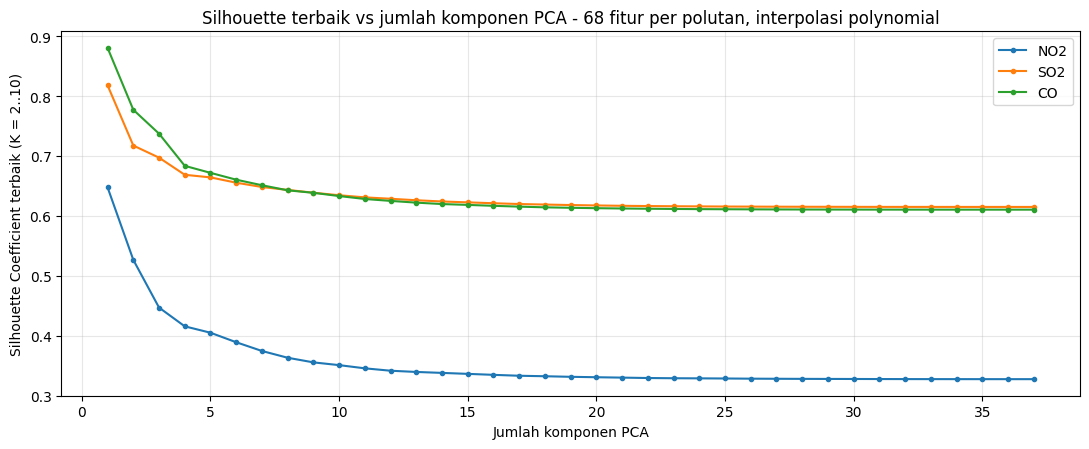

In [170]:
plot_sapuan(POLUTAN, "polynomial", "Silhouette terbaik vs jumlah komponen PCA - 68 fitur per polutan, interpolasi polynomial")

In [171]:
tabel_sapuan(POLUTAN, "polynomial")

,K_no2,sil_no2,K_so2,sil_so2,K_co,sil_co
n_komponen,,,,,,
1,3,0.6474,2,0.8178,2,0.8803
2,3,0.5264,2,0.7173,2,0.7770
3,3,0.4468,2,0.6971,2,0.7371
5,3,0.4048,2,0.6641,2,0.6717
10,3,0.3507,2,0.6343,2,0.6330
15,3,0.3361,2,0.6224,2,0.6182
20,3,0.3305,2,0.6173,2,0.6127
25,3,0.3284,2,0.6155,2,0.6110
30,3,0.3276,2,0.6149,2,0.6104


### 5.4 Penilaian Seberapa Baik Data Terkelompok

In [172]:
baris = []
for (nama, sk), h in hasil_analisis.items():
    e, et, sp = h["eval_pca"], h["eval_tanpa_pca"], h["sapuan"]
    b = e.loc[e["silhouette"].idxmax()]
    bt = et.loc[et["silhouette"].idxmax()]
    bs = sp.loc[sp["silhouette_terbaik"].idxmax()]
    baris.append({"data": nama, "skenario": sk, "n_fitur": h["n_fitur"], "K_terbaik": int(b["K"]),
                  "silhouette_pca37": round(float(b["silhouette"]), 4), "kategori": kategori_silhouette(b["silhouette"]),
                  "ukuran_cluster": b["ukuran_cluster"], "min_anggota": int(b["min_anggota"]),
                  "silhouette_tanpa_pca": round(float(bt["silhouette"]), 4),
                  "pca37_sama_tanpa_pca": bool(int(bt["K"]) == int(b["K"]) and abs(bt["silhouette"] - b["silhouette"]) < 1e-6),
                  "sapuan_tertinggi_pada": int(bs["n_komponen"]), "sapuan_silhouette": round(float(bs["silhouette_terbaik"]), 4)})
penilaian = pd.DataFrame(baris)
display(penilaian)

,data,skenario,n_fitur,K_terbaik,silhouette_pca37,kategori,ukuran_cluster,min_anggota,silhouette_tanpa_pca,pca37_sama_tanpa_pca,sapuan_tertinggi_pada,sapuan_silhouette
0,gabungan,linear,204,2,0.4909,lemah,"[34, 3]",3,0.4909,True,1,0.8412
1,gabungan,polynomial,204,2,0.5375,wajar,"[35, 2]",2,0.5375,True,1,0.8683
2,no2,linear,68,3,0.4562,lemah,"[4, 32, 1]",1,0.4562,True,1,0.7258
3,no2,polynomial,68,3,0.3273,lemah,"[8, 28, 1]",1,0.3273,True,1,0.6474
4,so2,linear,68,2,0.5159,wajar,"[34, 3]",3,0.5159,True,1,0.8372
5,so2,polynomial,68,2,0.6148,wajar,"[36, 1]",1,0.6148,True,1,0.8178
6,co,linear,68,2,0.5704,wajar,"[34, 3]",3,0.5704,True,1,0.8541
7,co,polynomial,68,2,0.6103,wajar,"[2, 35]",2,0.6103,True,1,0.8803


In [173]:
print("RINGKASAN ANALISIS JUMLAH CLUSTER")
print("=" * 70)
for _, r in penilaian.iterrows():
    print(f"- {r['data'].upper():9s} | {r['skenario']:10s} | K terbaik = {r['K_terbaik']} | silhouette = {r['silhouette_pca37']:.4f} ({r['kategori']}) | ukuran cluster = {r['ukuran_cluster']}")

if penilaian["pca37_sama_tanpa_pca"].all():
    print("\nPCA 37 komponen menghasilkan K dan silhouette yang sama dengan data tanpa PCA pada seluruh data. "
          f"Hal ini wajar karena jumlah sampel ({N_SAMPEL}) membuat PCA 37 komponen hanya merotasi ruang fitur tanpa mengubah jarak antar titik.")
else:
    beda = penilaian[~penilaian["pca37_sama_tanpa_pca"]][["data", "skenario"]].values.tolist()
    print("\nPCA 37 komponen berbeda dari data tanpa PCA pada:", beda)

kecil = penilaian[penilaian["min_anggota"] <= 2]
if len(kecil):
    print("\nCatatan: solusi terbaik berikut memuat cluster dengan 2 anggota atau kurang, sehingga skor tinggi kemungkinan berasal dari outlier:")
    print(kecil[["data", "skenario", "K_terbaik", "ukuran_cluster"]].to_string(index=False))

tertinggi = penilaian.loc[penilaian["silhouette_pca37"].idxmax()]
print(f"\nSilhouette tertinggi: data {tertinggi['data'].upper()}, interpolasi {tertinggi['skenario']}, "
      f"K = {tertinggi['K_terbaik']}, silhouette = {tertinggi['silhouette_pca37']:.4f} ({tertinggi['kategori']}).")

RINGKASAN ANALISIS JUMLAH CLUSTER
- GABUNGAN  | linear     | K terbaik = 2 | silhouette = 0.4909 (lemah) | ukuran cluster = [34, 3]
- GABUNGAN  | polynomial | K terbaik = 2 | silhouette = 0.5375 (wajar) | ukuran cluster = [35, 2]
- NO2       | linear     | K terbaik = 3 | silhouette = 0.4562 (lemah) | ukuran cluster = [4, 32, 1]
- NO2       | polynomial | K terbaik = 3 | silhouette = 0.3273 (lemah) | ukuran cluster = [8, 28, 1]
- SO2       | linear     | K terbaik = 2 | silhouette = 0.5159 (wajar) | ukuran cluster = [34, 3]
- SO2       | polynomial | K terbaik = 2 | silhouette = 0.6148 (wajar) | ukuran cluster = [36, 1]
- CO        | linear     | K terbaik = 2 | silhouette = 0.5704 (wajar) | ukuran cluster = [34, 3]
- CO        | polynomial | K terbaik = 2 | silhouette = 0.6103 (wajar) | ukuran cluster = [2, 35]

PCA 37 komponen menghasilkan K dan silhouette yang sama dengan data tanpa PCA pada seluruh data. Hal ini wajar karena jumlah sampel (37) membuat PCA 37 komponen hanya merotasi

**Cara membaca hasil.**

- **Jumlah cluster terbaik** adalah K dengan Silhouette Coefficient tertinggi. *Elbow Method* dipakai sebagai pembanding visual, yaitu titik tempat penurunan inertia mulai melandai.
- **Kualitas cluster (seberapa baik data terkelompok)** dinilai dari nilai silhouette: di atas 0,70 kuat, 0,51 sampai 0,70 wajar, 0,26 sampai 0,50 lemah, dan di bawah 0,25 tidak berstruktur.
- **Penyapuan PCA 1 sampai 37.** Skor tertinggi pada jumlah komponen yang sangat sedikit tidak otomatis berarti cluster lebih baik, karena pemampatan ke ruang berdimensi rendah membuat titik tampak lebih terpisah sambil membuang sebagian besar variasi asli. Hasil pada 37 komponen lebih representatif karena seluruh informasi masih terpertahankan.
- **Cluster beranggota sangat sedikit.** Silhouette tinggi dengan cluster berisi satu atau dua kecamatan umumnya menunjukkan outlier yang terpisah sendiri, bukan dua kelompok yang seimbang.

## 6. Hasil Clustering pada Tiap Dimensi

Setiap tingkat dimensi (203, 74, 37) diberi label cluster memakai K terbaiknya. Tabel label per kecamatan disimpan ke `hasil_clustering_<skenario>.csv`, dan Silhouette per cluster dihitung untuk kombinasi terbaik tiap skenario.

In [174]:
hasil_label = {}
for sk in SKENARIO:
    tabel = ident[sk].copy()
    for target in DIMENSI_TARGET:
        cocok = terbaik_kombinasi[(terbaik_kombinasi["skenario"] == sk) & (terbaik_kombinasi["dimensi_target"] == target)]
        if cocok.empty:
            print(f"[{sk}] dimensi {target}: tidak ada solusi yang memenuhi MIN_ANGGOTA = {MIN_ANGGOTA}, dilewati.")
            continue
        baris_terbaik = cocok.iloc[0]
        k = int(baris_terbaik["K"])
        tabel[f"cluster_dim{target}"] = label_store[(sk, target, k)]
        print(f"[{sk}] dimensi {target} (efektif {int(baris_terbaik['dimensi_efektif'])}): K = {k}, silhouette = {baris_terbaik['silhouette']:.4f}")
    hasil_label[sk] = tabel
    tabel.to_csv(f"hasil_clustering_{sk}.csv", index=False)
    print(f"Tabel label disimpan: hasil_clustering_{sk}.csv\n")

[linear] dimensi 203 (efektif 37): K = 2, silhouette = 0.4909
[linear] dimensi 74 (efektif 37): K = 2, silhouette = 0.4909
[linear] dimensi 37 (efektif 37): K = 2, silhouette = 0.4909
Tabel label disimpan: hasil_clustering_linear.csv

[polynomial] dimensi 203 (efektif 37): K = 2, silhouette = 0.5375
[polynomial] dimensi 74 (efektif 37): K = 2, silhouette = 0.5375
[polynomial] dimensi 37 (efektif 37): K = 2, silhouette = 0.5375
Tabel label disimpan: hasil_clustering_polynomial.csv



**Label cluster per kecamatan - interpolasi linier**

In [175]:
display(hasil_label["linear"].head(10))

,id,nama,daerah,cluster_dim203,cluster_dim74,cluster_dim37
0,1,Muhammad Ali Murtadho,Baron Nganjuk,0,0,0
1,2,Ainur Raftuzzaki,Nunukan,0,0,0
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",0,0,0
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",0,0,0
4,10,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0,0,0
5,11,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0,0,0
6,12,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0,0,0
7,13,Rian Renaldy,"Waru, Pamekasan",0,0,0
8,14,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0,0,0
9,15,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0,0,0


**Label cluster per kecamatan - interpolasi polynomial**

In [176]:
display(hasil_label["polynomial"].head(10))

,id,nama,daerah,cluster_dim203,cluster_dim74,cluster_dim37
0,1,Muhammad Ali Murtadho,Baron Nganjuk,0,0,0
1,2,Ainur Raftuzzaki,Nunukan,0,0,0
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",0,0,0
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",0,0,0
4,9,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0,0,0
5,10,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0,0,0
6,11,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0,0,0
7,12,Rian Renaldy,"Waru, Pamekasan",0,0,0
8,13,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0,0,0
9,14,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0,0,0


**Silhouette per cluster - interpolasi linier**

In [177]:
def silhouette_per_cluster(sk):
    r = terbaik_skenario[terbaik_skenario["skenario"] == sk].iloc[0]
    target, k = int(r["dimensi_target"]), int(r["K"])
    Z = representasi[sk][target]["Z"]
    lab = label_store[(sk, target, k)]
    s_sampel = silhouette_samples(Z, lab)
    per_cluster = pd.DataFrame({"cluster": lab, "silhouette": s_sampel}).groupby("cluster").agg(
        anggota=("silhouette", "size"), silhouette_rata2=("silhouette", "mean")).reset_index()
    print(f"Skenario {sk}, dimensi {target}, K = {k} (overall = {s_sampel.mean():.4f})")
    display(per_cluster)

silhouette_per_cluster("linear")

Skenario linear, dimensi 37, K = 2 (overall = 0.4909)


,cluster,anggota,silhouette_rata2
0,0,34,0.527904
1,1,3,0.071026


**Silhouette per cluster - interpolasi polynomial**

In [178]:
silhouette_per_cluster("polynomial")

Skenario polynomial, dimensi 37, K = 2 (overall = 0.5375)


,cluster,anggota,silhouette_rata2
0,0,35,0.560171
1,1,2,0.141623


Penjelasan kode di atas adalah sebagai berikut.


- Label cluster tiap dimensi ditulis ke kolom `cluster_dim203`, `cluster_dim74`, dan `cluster_dim37`.
- `silhouette_samples` dirata-ratakan per cluster; rata-rata keseluruhannya sama dengan `silhouette_score` pada bagian 4 dan menjadi pembanding keluaran KNIME.

### 6.1 Scatter Plot Hasil Clustering

Scatter plot memperlihatkan posisi tiap kecamatan pada bidang dua komponen utama pertama (PC1 dan PC2) dari representasi dimensi yang bersangkutan, diberi warna menurut cluster. Proyeksi dua dimensi ini hanya untuk visualisasi, sedangkan K-Means tetap dijalankan pada representasi dimensi yang bersangkutan. Nama kecamatan ditampilkan untuk cluster yang beranggota 3 atau kurang agar kecamatan yang terpisah dapat diidentifikasi.

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

PALET = ["#e6194B", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#9A6324", "#469990", "#800000", "#808000"]
BATAS_LABEL = 3   # tampilkan nama kecamatan untuk cluster berukuran <= BATAS_LABEL

def scatter_skenario(sk):
    fig, axes = plt.subplots(1, len(DIMENSI_TARGET), figsize=(5.4 * len(DIMENSI_TARGET), 4.8), squeeze=False)
    for ax, target in zip(axes[0], DIMENSI_TARGET):
        cocok = terbaik_kombinasi[(terbaik_kombinasi["skenario"] == sk) & (terbaik_kombinasi["dimensi_target"] == target)]
        if cocok.empty:
            ax.axis("off")
            continue
        r = cocok.iloc[0]
        k = int(r["K"])
        Z = representasi[sk][target]["Z"]
        lab = label_store[(sk, target, k)]
        pca2 = PCA(n_components=2, random_state=42).fit(Z)
        Z2 = pca2.transform(Z)
        var = pca2.explained_variance_ratio_ * 100
        ukuran = np.bincount(lab)
        for cl in sorted(set(lab)):
            m = lab == cl
            ax.scatter(Z2[m, 0], Z2[m, 1], s=70, c=PALET[int(cl) % len(PALET)], edgecolors="black",
                       label=f"Cluster {cl} (n = {int(m.sum())})", zorder=3)
        for i in np.where(ukuran[lab] <= BATAS_LABEL)[0]:
            ax.annotate(ident[sk].iloc[i]["nama"], (Z2[i, 0], Z2[i, 1]), fontsize=7, xytext=(5, 5), textcoords="offset points")
        ax.set_title(f"Dimensi {target} | K = {k} | silhouette = {r['silhouette']:.3f}", fontsize=10)
        ax.set_xlabel(f"PC1 ({var[0]:.1f}% variansi)")
        ax.set_ylabel(f"PC2 ({var[1]:.1f}% variansi)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.suptitle(f"Scatter Plot Hasil Clustering - interpolasi {sk}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"scatter_plot_{sk}.png", dpi=150)
    plt.show()

**Scatter plot - interpolasi linier**

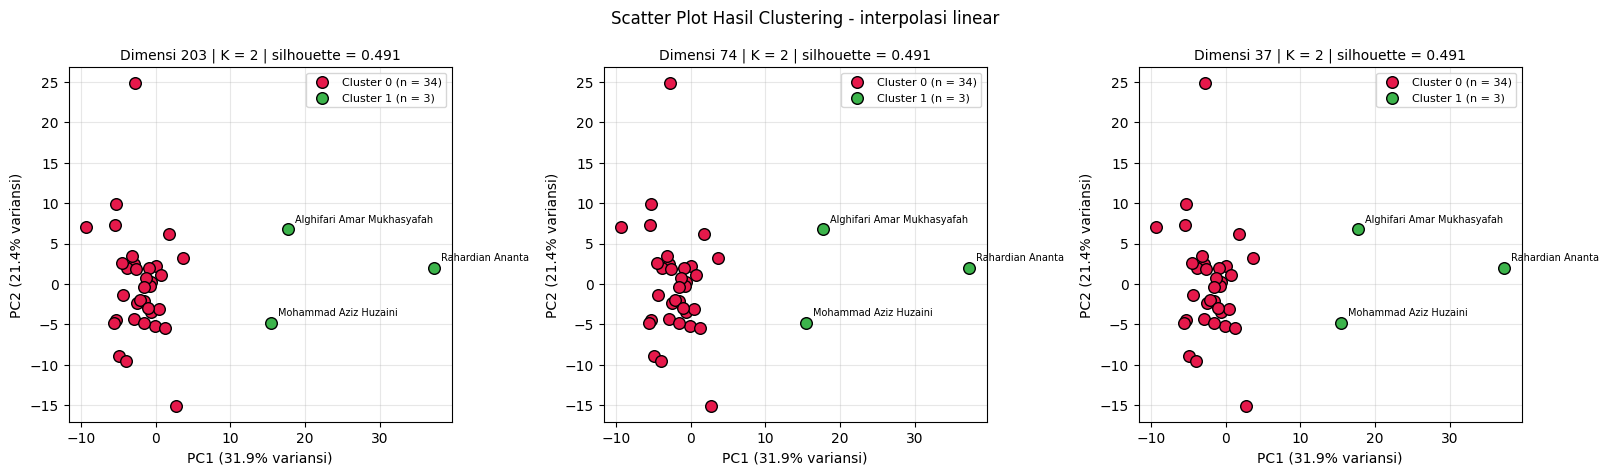

In [180]:
scatter_skenario("linear")

**Scatter plot - interpolasi polynomial**

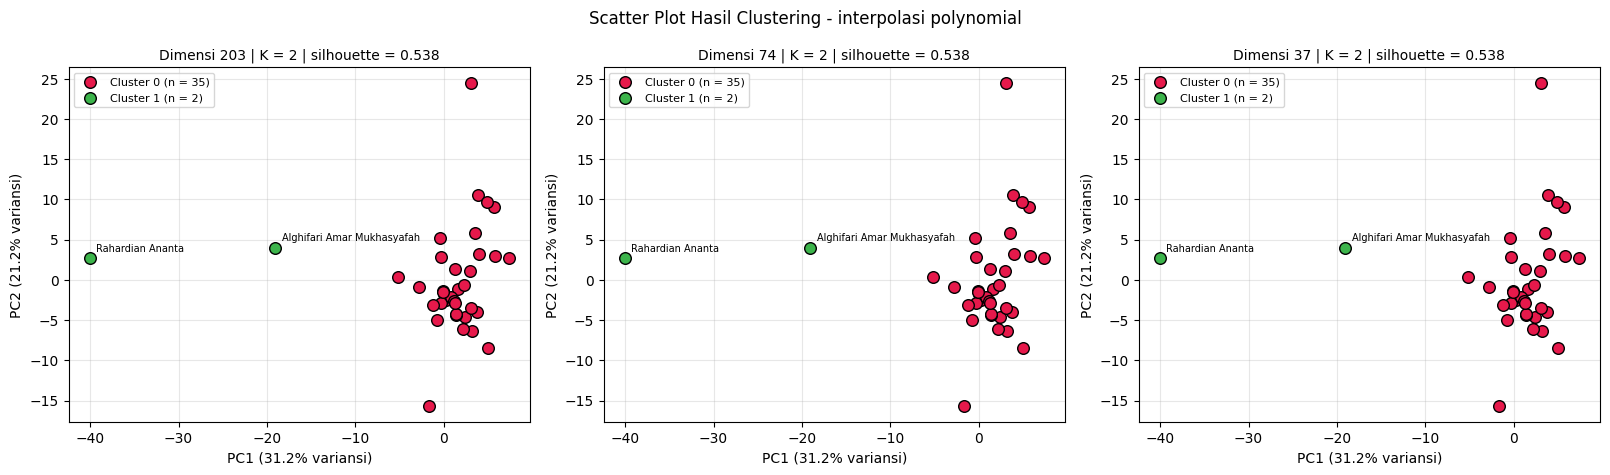

In [181]:
scatter_skenario("polynomial")

Penjelasan kode di atas adalah sebagai berikut.

- Untuk tiap kombinasi skenario × dimensi, label cluster terbaik diambil dari `label_store`, lalu representasi `Z` diproyeksikan ke dua komponen utama dengan `PCA(n_components=2)` hanya untuk menggambar.
- Sumbu menampilkan persentase variansi yang dijelaskan PC1 dan PC2, sehingga pembaca dapat menilai seberapa representatif proyeksi dua dimensi tersebut.
- Tiga kolom (dimensi 203, 74, 37) tampak serupa karena label dan jarak antar titik identik, sebagaimana dijelaskan pada bagian 3.

**Interpretasi.** Titik berwarna cluster kecil dibaca terhadap gugus titik cluster besar: semakin jauh posisinya dari gugus utama, semakin berbeda pola polutannya. Bila ukuran cluster sangat timpang (misalnya satu kelompok besar dan satu kelompok 2 sampai 3 kecamatan), cluster kecil merupakan kecamatan dengan karakteristik fitur menyimpang, bukan kelompok berukuran seimbang.

## 7. Peta Hasil Clustering (Segmentasi Wilayah)

Kecamatan diplot pada peta menurut koordinatnya dan diberi warna sesuai cluster sehingga segmen wilayah terlihat jelas. Seluruh daerah yang ada di basis data dipetakan. Koordinat diperoleh dari kolom `daerah` dengan *geocoding* (OpenStreetMap Nominatim) dan disimpan di `koordinat_kecamatan.csv`. Bila geocoding gagal karena penulisan nama yang tidak baku, dipakai koordinat manual (perkiraan pusat kecamatan) pada `KOORDINAT_MANUAL`.

In [182]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_KOORDINAT = "koordinat_kecamatan.csv"

# Kotak batas wilayah Indonesia, hanya untuk menolak hasil geocoding yang jatuh di luar negeri
BBOX_LAT = (-11.5, 6.5)
BBOX_LON = (94.5, 141.5)

# Koordinat cadangan (perkiraan pusat kecamatan) untuk penulisan daerah yang tidak dikenali geocoder.
# Dipakai hanya bila geocoding gagal; periksa kembali bila diperlukan ketepatan tinggi.
KOORDINAT_MANUAL = {
    "Nunukan": (4.0730, 117.6540),
    "Tikala, Manado": (1.4790, 124.8650),
    "Warudoyong, Kota Sukabumi": (-6.9150, 106.9100),
    "Bandung - Jogoroto, Jombang": (-7.5890, 112.2850),
    "Banyu Ajuh, Perumnas, Kamal": (-7.1560, 112.7230),
    "Kec. Kalianget, Sumenep": (-7.0500, 113.9300),
}

def kandidat_query(daerah):
    d = " ".join(str(daerah).replace("Kec.", "").replace(" - ", " ").split())
    if "," in d:
        kec, kab = [s.strip() for s in d.split(",", 1)]
        return [f"Kecamatan {kec}, {kab}, Indonesia", f"{kec}, {kab}, Indonesia", f"{kec}, Indonesia"]
    return [f"Kecamatan {d}, Indonesia", f"{d}, Indonesia"]

def dalam_bbox(lat, lon):
    return BBOX_LAT[0] <= lat <= BBOX_LAT[1] and BBOX_LON[0] <= lon <= BBOX_LON[1]

def muat_koordinat(daftar_daerah):
    kd = pd.read_csv(FILE_KOORDINAT) if os.path.exists(FILE_KOORDINAT) else pd.DataFrame(columns=["daerah", "lat", "lon"])
    sudah = set(kd.dropna(subset=["lat", "lon"])["daerah"])
    belum = [d for d in dict.fromkeys(daftar_daerah) if d not in sudah]
    if belum:
        print(f"Geocoding {len(belum)} daerah yang belum punya koordinat...")
        geocode = None
        try:
            from geopy.geocoders import Nominatim
            geocode = Nominatim(user_agent="tugas-clustering-polutan-udara", timeout=10).geocode
        except Exception as e:
            print("geopy tidak tersedia/gagal:", repr(e)[:120])
        baru = []
        for d in belum:
            lat = lon = np.nan
            if geocode is not None:
                for q in kandidat_query(d):
                    try:
                        hasil = geocode(q)
                    except Exception:
                        hasil = None
                    time.sleep(1.1)                      # patuhi batas 1 permintaan/detik Nominatim
                    if hasil is not None and dalam_bbox(hasil.latitude, hasil.longitude):
                        lat, lon = hasil.latitude, hasil.longitude
                        break
            if np.isnan(lat) and d in KOORDINAT_MANUAL:
                lat, lon = KOORDINAT_MANUAL[d]
                print(f"  koordinat manual dipakai untuk: {d}")
            baru.append({"daerah": d, "lat": lat, "lon": lon})
        baru = pd.DataFrame(baru)
        kd = pd.concat([kd[~kd["daerah"].isin(belum)], baru], ignore_index=True) if len(kd) else baru
        kd.to_csv(FILE_KOORDINAT, index=False)
    return kd.drop_duplicates("daerah", keep="last")

semua_daerah = pd.concat([ident[sk]["daerah"] for sk in SKENARIO]).dropna().unique().tolist()
koordinat = muat_koordinat(semua_daerah)

gagal = koordinat[koordinat[["lat", "lon"]].isna().any(axis=1)]
print(f"Koordinat berhasil: {len(koordinat) - len(gagal)} dari {len(koordinat)} daerah.")
if len(gagal):
    print(f"Isi manual lat/lon pada '{FILE_KOORDINAT}' (atau tambahkan ke KOORDINAT_MANUAL) untuk daerah berikut, lalu jalankan ulang sel ini:")
    print(gagal["daerah"].tolist())

Koordinat berhasil: 36 dari 36 daerah.


**Pemeriksaan koordinat**

In [183]:
ada = koordinat.dropna(subset=["lat", "lon"])
kembar = ada[ada.duplicated(["lat", "lon"], keep=False)].sort_values(["lat", "lon"])
if len(kembar):
    print("Daerah dengan koordinat identik (kemungkinan hasil geocoding tingkat kabupaten; periksa bila perlu):")
    print(kembar.groupby(["lat", "lon"])["daerah"].apply(list).tolist())
else:
    print("Tidak ada koordinat yang identik.")
display(koordinat.head(10))

Daerah dengan koordinat identik (kemungkinan hasil geocoding tingkat kabupaten; periksa bila perlu):
[['Baron Nganjuk', 'Kertosono, Nganjuk'], ['Jabon , Sidoarjo', 'Jabon, Sidoarjo'], ['Manyar, Gresik', 'Cerme, Gresik'], ['Bangkalan, Bangkalan', 'Kecamatan Bangkalan,Bangkalan']]


,daerah,lat,lon
0,Baron Nganjuk,-7.607117,112.051032
1,Nunukan,4.134465,117.645168
2,"Sreseh, Sampang",-7.219002,113.132860
3,"Manyar, Gresik",-7.234772,112.564431
4,"Kamal, Bangkalan",-7.170282,112.728856
5,Kedungpring Lamongan,-7.184395,112.198296
6,"Gresik Kota, Gresik",-7.206313,112.638691
7,"Waru, Pamekasan",-6.941817,113.551512
8,"Paciran, Lamongan",-6.870348,112.339679
9,"Kertosono, Nganjuk",-7.607117,112.051032


Penjelasan kode di atas adalah sebagai berikut.

- `kandidat_query()` menyusun variasi pencarian dari kolom `daerah` (nama kecamatan, kabupaten, lalu Indonesia).
- `dalam_bbox()` hanya menolak hasil di luar wilayah Indonesia, sehingga seluruh daerah pada basis data tetap dipetakan.
- `KOORDINAT_MANUAL` menjadi cadangan untuk penulisan daerah yang tidak baku sehingga tidak dikenali geocoder; hasil geocoding disimpan sebagai cache dengan jeda sesuai batas Nominatim.
- Keluaran menampilkan jumlah daerah yang berhasil dipetakan dan peringatan bila ada koordinat yang identik.

In [184]:
import os
import folium
from IPython.display import display as tampilkan

WARNA = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "pink", "black",
]

# Susun label cluster (K terbaik) untuk setiap kombinasi skenario x dimensi
koordinat_daerah = koordinat
hasil_per_kombinasi = {}   # (skenario, dimensi) -> tabel identitas + kolom cluster
hasil_k = {}               # (skenario, dimensi) -> K terbaik dan silhouette-nya

for sk in SKENARIO:
    for dim in DIMENSI_TARGET:
        cocok = terbaik_kombinasi[(terbaik_kombinasi["skenario"] == sk) & (terbaik_kombinasi["dimensi_target"] == dim)]
        if cocok.empty:
            continue
        r = cocok.iloc[0]
        k = int(r["K"])
        df_hasil = ident[sk].copy()
        df_hasil["cluster"] = label_store[(sk, dim, k)]
        hasil_per_kombinasi[(sk, dim)] = df_hasil
        hasil_k[(sk, dim)] = {"k_terbaik": k, "silhouette_terbaik": float(r["silhouette"])}

Penjelasan kode di atas adalah sebagai berikut.

- `hasil_per_kombinasi` menyimpan tabel identitas kecamatan beserta label cluster dari K terbaik untuk setiap skenario × dimensi (203, 74, 37), diambil dari `label_store`.
- `hasil_k` menyimpan K terbaik dan nilai silhouette-nya untuk judul peta.
- Peta dibuat dengan **Folium** memakai citra satelit Esri World Imagery sebagai peta dasar (tile OpenStreetMap standar diblokir di Colab).

In [185]:
os.makedirs("peta_hasil", exist_ok=True)

def peta_folium(skenario, dimensi):
    """Menampilkan satu peta clustering (citra satelit Esri) untuk satu skenario x dimensi."""
    if (skenario, dimensi) not in hasil_per_kombinasi:
        print(f"Tidak ada hasil untuk skenario {skenario}, dimensi {dimensi}.")
        return
    hasil = hasil_k[(skenario, dimensi)]
    df_hasil = hasil_per_kombinasi[(skenario, dimensi)]

    data_peta = df_hasil.merge(koordinat_daerah, on="daerah", how="left")
    data_peta = data_peta.dropna(subset=["lat", "lon"])

    print(
        f"=== Skenario: {skenario} | Dimensi: {dimensi} | "
        f"K final = {hasil['k_terbaik']} | Silhouette = {hasil['silhouette_terbaik']:.4f} ==="
    )

    if len(data_peta) == 0:
        print("Tidak ada koordinat yang berhasil ditemukan untuk kombinasi ini.")
        return

    pusat_lat = data_peta["lat"].median()
    pusat_lon = data_peta["lon"].median()

    peta = folium.Map(
        location=[pusat_lat, pusat_lon],
        zoom_start=9,
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
    )

    warna_cluster = {
        c: WARNA[i % len(WARNA)]
        for i, c in enumerate(sorted(data_peta["cluster"].unique()))
    }

    for _, baris in data_peta.iterrows():
        folium.CircleMarker(
            location=[baris["lat"], baris["lon"]],
            radius=7,
            color=warna_cluster[baris["cluster"]],
            fill=True,
            fill_color=warna_cluster[baris["cluster"]],
            fill_opacity=0.85,
            tooltip=f"{baris['nama']} | {baris['daerah']} | cluster {baris['cluster']}",
            popup=f"{baris['daerah']} (cluster {baris['cluster']})",
        ).add_to(peta)

    # Zoom ke gugus utama titik (mis. Jawa Timur) agar tekstur citra satelit terlihat jelas.
    # Daerah yang jauh (mis. Nunukan, Manado) tetap ada di peta: zoom-out/geser untuk melihatnya.
    inti = data_peta[(data_peta["lat"].sub(pusat_lat).abs() <= 2) & (data_peta["lon"].sub(pusat_lon).abs() <= 2)]
    peta.fit_bounds([[inti["lat"].min(), inti["lon"].min()], [inti["lat"].max(), inti["lon"].max()]], padding=(30, 30))
    jauh = len(data_peta) - len(inti)
    if jauh:
        print(f"({jauh} titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)")

    # Legenda cluster
    n_cl = data_peta["cluster"].value_counts()
    isi = "".join(
        f'<div><span style="background:{warna_cluster[c]};display:inline-block;width:12px;height:12px;'
        f'border-radius:50%;margin-right:6px"></span>Cluster {c} (n = {n_cl[c]})</div>'
        for c in sorted(warna_cluster)
    )
    peta.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;bottom:20px;left:20px;z-index:9999;background:white;padding:8px 10px;'
        f'border:1px solid #888;border-radius:6px;font-size:12px"><b>{skenario} | dim {dimensi} | K = {hasil["k_terbaik"]}</b>{isi}</div>'
    ))

    peta.save(f"peta_hasil/peta_{skenario}_dim{dimensi}_k{hasil['k_terbaik']}.html")
    tampilkan(peta)

Fungsi `peta_folium(skenario, dimensi)` menampilkan satu peta per pemanggilan (juga menyimpannya sebagai HTML di folder `peta_hasil`). Setiap dimensi dipanggil pada sel terpisah di bawah agar keluaran mudah dibaca.

### 7.1 Peta Interpolasi Linier

**Dimensi 203**

In [186]:
peta_folium("linear", DIMENSI_TARGET[0])

=== Skenario: linear | Dimensi: 203 | K final = 2 | Silhouette = 0.4909 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


**Dimensi 74**

In [187]:
peta_folium("linear", 74)

=== Skenario: linear | Dimensi: 74 | K final = 2 | Silhouette = 0.4909 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


**Dimensi 37**

In [188]:
peta_folium("linear", 37)

=== Skenario: linear | Dimensi: 37 | K final = 2 | Silhouette = 0.4909 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


### 7.2 Peta Interpolasi Polynomial

**Dimensi 203**

In [189]:
peta_folium("polynomial", DIMENSI_TARGET[0])

=== Skenario: polynomial | Dimensi: 203 | K final = 2 | Silhouette = 0.5375 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


**Dimensi 74**

In [190]:
peta_folium("polynomial", 74)

=== Skenario: polynomial | Dimensi: 74 | K final = 2 | Silhouette = 0.5375 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


**Dimensi 37**

In [191]:
peta_folium("polynomial", 37)

=== Skenario: polynomial | Dimensi: 37 | K final = 2 | Silhouette = 0.5375 ===
(3 titik berada jauh di luar bingkai awal; zoom-out untuk melihatnya)


### 7.3 Segmentasi Daerah per Cluster

Daftar kecamatan pada tiap cluster untuk kombinasi terbaik setiap skenario.

In [192]:
for sk in SKENARIO:
    r = terbaik_skenario[terbaik_skenario["skenario"] == sk].iloc[0]
    dim = int(r["dimensi_target"])
    df_hasil = hasil_per_kombinasi[(sk, dim)]
    print(f"Skenario {sk} | dimensi {dim} | K = {hasil_k[(sk, dim)]['k_terbaik']}")
    seg = df_hasil.groupby("cluster")["daerah"].apply(lambda s: "; ".join(sorted(s.unique()))).reset_index(name="daerah_anggota")
    seg.insert(1, "jumlah", df_hasil.groupby("cluster").size().values)
    display(seg)
    seg.to_csv(f"segmentasi_wilayah_{sk}.csv", index=False)

Skenario linear | dimensi 37 | K = 2


,cluster,jumlah,daerah_anggota
0,0,34,"Asemrowo, Surabaya; Bandung - Jogoroto, Jomban..."
1,1,3,"Jabon , Sidoarjo; Sidoarjo, Wonoayu; Tanah Mer..."


Skenario polynomial | dimensi 37 | K = 2


,cluster,jumlah,daerah_anggota
0,0,35,"Asemrowo, Surabaya; Bandung - Jogoroto, Jomban..."
1,1,2,"Jabon, Sidoarjo; Sidoarjo, Wonoayu"


**Interpretasi.** Cluster kecil pada peta biasanya berisi beberapa kecamatan yang pola polutannya menyimpang dari kelompok besar. Karena label cluster ditentukan oleh kemiripan pola polutan, bukan oleh letak geografis, segmen yang terbentuk tidak harus mengikuti batas wilayah administrasi. Bila dimensi 203, 74, dan 37 memberi label yang sama, ketiga peta untuk satu skenario akan identik.

## 8. Implementasi Alur Kerja (Workflow) Clustering KNIME
![image](https://hackmd.io/_uploads/ByUIW-esGe.png)

Diagram di atas menampilkan alur kerja K-Means Clustering pada KNIME yang mengulang proses Python. Alur dijalankan terpisah untuk skenario linier dan polynomial, masing-masing dengan tiga cabang PCA (203, 74, 37), sehingga terdapat enam cabang. Fungsi setiap node adalah sebagai berikut.

### 8.1 MySQL Connector

Menghubungkan KNIME dengan database MySQL (Aiven) tempat tabel hasil ekstraksi fitur disimpan. Kredensial disimpan melalui *Workflow Credentials* agar password tidak tertulis pada node.

> ![image](https://hackmd.io/_uploads/H1bm0beozg.png)

### 8.2 DB Table Selector

Memilih tabel sumber tiap skenario, yaitu `ekstraksi_fitur_linear` dan `ekstraksi_fitur_polynomial`, sebagai dua cabang paralel.

> ![image](https://hackmd.io/_uploads/SJ8IRbljze.png)

*Contoh pada table ini memilih: ekstraksi_fitur_linear*

### 8.3 DB Reader

Membaca tabel terpilih ke KNIME: tiga kolom identitas (`id`, `nama`, `daerah`) dan 204 kolom fitur gabungan NO2, SO2, dan CO untuk 37 kecamatan.

> ![image](https://hackmd.io/_uploads/ryYT0Wxjfx.png)

*Contoh pada node ini membaca: ekstraksi_fitur_linear*



### 8.4 PCA (203 → 74 → 37)

Mereduksi 204 fitur menjadi komponen utama sesuai *Target dimensions* (203, 74, atau 37). Jumlah komponen dibatasi jumlah baris data (37 kecamatan), sehingga ketiga cabang menghasilkan 37 komponen yang sama dan hasil clustering identik.

> ![image](https://hackmd.io/_uploads/r1ZwkzxsMx.png)

*Contoh pada node ini Number of demensinya pada: ekstraksi_fitur_linear (37)*

### 8.5 k-Means

Mengelompokkan kecamatan ke dalam *k* = 2 cluster pada hasil PCA, sesuai K terbaik eksperimen Python (bagian 4), dan menambahkan kolom label cluster. Hasil: cluster_0 menjadi kelompok mayoritas dan cluster_1 kelompok kecil (4 kecamatan pada linier dan 6 pada polynomial).

> ![image](https://hackmd.io/_uploads/rJzJxMljfl.png)

### 8.6 Scatter Plot

Menampilkan nama kecamatan (sumbu x) terhadap label cluster (sumbu y); setiap titik mewakili satu kecamatan. Hasil: hampir seluruh kecamatan berada di cluster_0, dan hanya sedikit kecamatan yang terpisah di cluster_1. Gambar sama pada dimensi 203, 74, dan 37.

dimensi 37

> ![image](https://hackmd.io/_uploads/Skyt8Ggsze.png)

### 8.7 Silhouette Coefficient

Mengukur kualitas pemisahan cluster secara numerik, per cluster maupun keseluruhan (*overall*). Hasil: overall 0,822 pada linier (kategori kuat) dan 0,634 pada polynomial (kategori wajar), sama pada ketiga dimensi. Perbandingan dengan Python ada pada bagian 9.

> ![image](https://hackmd.io/_uploads/Sy7KLzlsGl.png)

### 8.8 Hasil Clustering Setiap Skenario (Scatter Plot & Silhouette Coefficient KNIME)

#### 8.8.1 Skenario Linier (`ekstraksi_fitur_linear`)

##### 8.8.1.1 Dimensi 37

> ![image](https://hackmd.io/_uploads/B1XqQfxifl.png)

> ![L37](https://hackmd.io/_uploads/r1yVrzgifg.png)


Overall 0,822 dengan K = 2. Cluster_0 bersilhouette 0,878, sedangkan cluster_1 yang hanya berisi 4 kecamatan bersilhouette 0,357 (struktur lemah).

##### 8.8.1.2 Dimensi 74

> ![image](https://hackmd.io/_uploads/SknpXGxsGg.png)

> ![L74](https://hackmd.io/_uploads/HJy4rfeiGe.png)

Identik dengan dimensi 37 (overall 0,822) karena komponen PCA dibatasi 37.

##### 8.8.1.3 Dimensi 203

> ![image](https://hackmd.io/_uploads/HyjAQfgsMx.png)

> ![L203](https://hackmd.io/_uploads/HkyNrMlofg.png)

Identik dengan dimensi 37 dan 74 (overall 0,822).

#### 8.8.2 Skenario Polynomial (`ekstraksi_fitur_polynomial`)

##### 8.8.2.1 Dimensi 37

> ![image](https://hackmd.io/_uploads/B1uySfesze.png)

> ![P37](https://hackmd.io/_uploads/SJJNHMejfe.png)

Overall 0,634 dengan K = 2. Cluster_0 bersilhouette 0,692, sedangkan cluster_1 berisi 6 kecamatan dengan silhouette 0,335 (struktur lemah).

##### 8.8.2.2 Dimensi 74

> ![image](https://hackmd.io/_uploads/B1uySfesze.png)

> ![P74](https://hackmd.io/_uploads/Sk1VrfloMg.png)

Identik dengan dimensi 37 (overall 0,634) karena komponen PCA dibatasi 37.

##### 8.8.2.3 Dimensi 203

> ![image](https://hackmd.io/_uploads/B1uySfesze.png)

> ![P203](https://hackmd.io/_uploads/r1yNBfesfe.png)

Identik dengan dimensi 37 dan 74 (overall 0,634).

**Ringkasan.** Pada kedua skenario K-Means menghasilkan 2 cluster yang identik di dimensi 203, 74, dan 37. Skenario linier memiliki silhouette lebih tinggi (0,822) dibanding polynomial (0,634), tetapi cluster kecilnya lemah (silhouette 0,357 dan 0,335) sehingga segmentasi didominasi satu kelompok besar.

**Konfigurasi node k-Means dan Scatter Plot pada KNIME**

Tabel berikut diisi otomatis dari eksperimen bagian 4, sehingga nilai *k* tiap cabang KNIME sesuai dengan hasil Python.

In [193]:
from sklearn.metrics import adjusted_rand_score

NAMA_TABEL_TAMPIL = {"linear": "Linear", "polynomial": "Polynomial"}

baris = []
for sk in SKENARIO:
    for target in DIMENSI_TARGET:
        r = terbaik_kombinasi[(terbaik_kombinasi["skenario"] == sk) & (terbaik_kombinasi["dimensi_target"] == target)]
        if r.empty:
            continue
        r = r.iloc[0]
        k, d_eff = int(r["K"]), int(r["dimensi_efektif"])
        isi = f"Nama kecamatan vs label cluster dari reduksi {target} dimensi"
        if d_eff != target:
            isi += f" ({d_eff} komponen efektif)"
        isi += f"; titik diwarnai menurut {k} cluster"
        baris.append({"Tabel": NAMA_TABEL_TAMPIL[sk], "Dimensi PCA": target, "Komponen efektif": d_eff,
                      "K": k, "Isi Scatter Plot": isi})
tabel_knime = pd.DataFrame(baris)
display(tabel_knime)

# Pemeriksaan: bila dimensi efektif sama, K dan label cluster antar dimensi seharusnya identik
for sk in SKENARIO:
    sub = tabel_knime[tabel_knime["Tabel"] == NAMA_TABEL_TAMPIL[sk]]
    lab = [label_store[(sk, int(x["Dimensi PCA"]), int(x["K"]))] for _, x in sub.iterrows()]
    identik = all(adjusted_rand_score(lab[0], l) == 1.0 for l in lab[1:])
    print(f"[{sk}] K per dimensi = {sub['K'].tolist()} | label cluster identik antar dimensi: {identik}")

,Tabel,Dimensi PCA,Komponen efektif,K,Isi Scatter Plot
0,Linear,203,37,2,Nama kecamatan vs label cluster dari reduksi 2...
1,Linear,74,37,2,Nama kecamatan vs label cluster dari reduksi 7...
2,Linear,37,37,2,Nama kecamatan vs label cluster dari reduksi 3...
3,Polynomial,203,37,2,Nama kecamatan vs label cluster dari reduksi 2...
4,Polynomial,74,37,2,Nama kecamatan vs label cluster dari reduksi 7...
5,Polynomial,37,37,2,Nama kecamatan vs label cluster dari reduksi 3...


[linear] K per dimensi = [2, 2, 2] | label cluster identik antar dimensi: True
[polynomial] K per dimensi = [2, 2, 2] | label cluster identik antar dimensi: True


## 9. Perbandingan Hasil Python dan KNIME

Hasil Silhouette Coefficient dari Python dibandingkan dengan keluaran node Silhouette Coefficient pada KNIME untuk tiap skenario dan dimensi. Kolom Python terisi otomatis dari eksperimen bagian 4, sedangkan kolom KNIME diisi dari nilai *overall* pada node KNIME.

In [194]:
perbandingan = terbaik_kombinasi[["skenario", "dimensi_target", "dimensi_efektif", "K", "silhouette", "ukuran_cluster"]].copy()
perbandingan = perbandingan.rename(columns={"dimensi_target": "dimensi", "silhouette": "silhouette_python"})
perbandingan["silhouette_python"] = perbandingan["silhouette_python"].round(4)
# Nilai overall dari node Silhouette Coefficient KNIME (sama pada dimensi 203, 74, 37)
knime_overall = {"linear": 0.822, "polynomial": 0.634}
# Ukuran cluster KNIME dibaca dari scatter plot (cluster_0, cluster_1)
knime_ukuran = {"linear": [33, 4], "polynomial": [31, 6]}
perbandingan["silhouette_knime"] = perbandingan["skenario"].map(knime_overall)
perbandingan["ukuran_cluster_knime"] = perbandingan["skenario"].map(knime_ukuran)
display(perbandingan)

,skenario,dimensi,dimensi_efektif,K,silhouette_python,ukuran_cluster,silhouette_knime,ukuran_cluster_knime
0,linear,203,37,2,0.4909,"[34, 3]",0.822,"[33, 4]"
1,linear,74,37,2,0.4909,"[34, 3]",0.822,"[33, 4]"
2,linear,37,37,2,0.4909,"[34, 3]",0.822,"[33, 4]"
3,polynomial,203,37,2,0.5375,"[35, 2]",0.634,"[31, 6]"
4,polynomial,74,37,2,0.5375,"[35, 2]",0.634,"[31, 6]"
5,polynomial,37,37,2,0.5375,"[35, 2]",0.634,"[31, 6]"


Hasil KNIME dan Python sama pada K (2), pada kesamaan hasil antar dimensi 203, 74, dan 37, serta pada pola satu cluster mayoritas dan satu cluster kecil. Namun skor dan ukuran cluster berbeda: silhouette KNIME 0,822 (linier) dan 0,634 (polynomial) terhadap Python 0,4909 dan 0,5375, ukuran cluster KNIME [33, 4] dan [31, 6] terhadap Python [34, 3] dan [35, 2], dan skenario dengan silhouette tertinggi berbalik. Selisih sebesar ini kemungkinan bukan sekadar akibat inisialisasi pusat cluster, sehingga perlu dicek apakah praproses KNIME (misalnya standardisasi sebelum PCA) sama dengan Python. Perbandingan angka antar alat karena itu dibaca sebagai kesamaan pola, bukan kesamaan nilai.

## Kesimpulan

Ringkasan berikut dibangkitkan dari hasil eksperimen pada sel di bawah sehingga angkanya selalu sesuai dengan data yang dijalankan.

In [195]:
print("RINGKASAN HASIL EKSPERIMEN CLUSTERING")
print("=" * 70)
print(f"Sumber data      : {sumber_data}")
print(f"Jumlah sampel    : {N_SAMPEL} kecamatan")
print(f"Jumlah fitur     : {X_scaled['linear'].shape[1]} (linier), {X_scaled['polynomial'].shape[1]} (polynomial) setelah praproses")
print(f"Dimensi diuji    : {DIMENSI_TARGET}; K diuji: {K_RANGE[0]} sampai {K_RANGE[-1]}")
print()
for _, r in terbaik_skenario.iterrows():
    ukuran = r["ukuran_cluster"]
    print(f"- Skenario {r['skenario']}: terbaik pada dimensi {int(r['dimensi_target'])} "
          f"(efektif {int(r['dimensi_efektif'])}), K = {int(r['K'])}, silhouette = {r['silhouette']:.4f}, ukuran cluster = {ukuran}")
print()
print(f"Kombinasi terbaik keseluruhan: skenario {terbaik_global['skenario']}, dimensi {int(terbaik_global['dimensi_target'])}, "
      f"K = {int(terbaik_global['K'])}, silhouette = {terbaik_global['silhouette']:.4f}")

tunggal = terbaik_skenario[terbaik_skenario["min_anggota"] < 2]
if len(tunggal):
    print("\nCatatan interpretasi: solusi terbaik pada skenario "
          f"{', '.join(tunggal['skenario'])} memuat cluster beranggota tunggal. Skor silhouette yang tinggi pada kondisi ini "
          "umumnya berasal dari satu kecamatan dengan nilai fitur ekstrem (outlier) yang dipisahkan sendiri, bukan dari "
          "segmentasi wilayah yang seimbang. Jalankan ulang dengan MIN_ANGGOTA = 2 untuk melihat solusi terbaik tanpa cluster tunggal.")
else:
    print("\nSemua solusi terbaik memiliki cluster dengan minimal 2 anggota.")

dim_sama = tabel_dimensi.groupby("skenario")["dimensi_efektif"].nunique()
if (dim_sama < len(DIMENSI_TARGET)).any():
    print(f"Catatan dimensi: karena jumlah sampel ({N_SAMPEL}) membatasi jumlah komponen PCA, sebagian dimensi target "
          "memiliki dimensi efektif yang sama dan hasil clustering-nya identik.")

RINGKASAN HASIL EKSPERIMEN CLUSTERING
Sumber data      : MySQL (Aiven)
Jumlah sampel    : 37 kecamatan
Jumlah fitur     : 204 (linier), 204 (polynomial) setelah praproses
Dimensi diuji    : [203, 74, 37]; K diuji: 2 sampai 10

- Skenario linear: terbaik pada dimensi 37 (efektif 37), K = 2, silhouette = 0.4909, ukuran cluster = [34, 3]
- Skenario polynomial: terbaik pada dimensi 37 (efektif 37), K = 2, silhouette = 0.5375, ukuran cluster = [35, 2]

Kombinasi terbaik keseluruhan: skenario polynomial, dimensi 37, K = 2, silhouette = 0.5375

Semua solusi terbaik memiliki cluster dengan minimal 2 anggota.
Catatan dimensi: karena jumlah sampel (37) membatasi jumlah komponen PCA, sebagian dimensi target memiliki dimensi efektif yang sama dan hasil clustering-nya identik.


### Kesimpulan Akademis

Angka rinci tersedia pada ringkasan otomatis di sel sebelumnya; poin berikut adalah kerangka kesimpulannya.

1. **Data dan dimensi.** Gabungan tiga polutan menghasilkan 204 fitur, dan seluruhnya dipertahankan (tanpa pembuangan kolom) pada kedua skenario sehingga perhitungan linier dan polynomial setara. Dengan hanya 37 kecamatan, reduksi 203 → 74 → 37 menghasilkan representasi yang setara secara jarak sehingga hasil clustering identik pada dimensi yang dibatasi 37 komponen.
2. **Jumlah cluster terbaik.** K terbaik ditentukan dari Silhouette Coefficient tertinggi pada eksperimen K = 2 sampai 10; nilainya dibandingkan antara interpolasi linier dan polynomial dan dikategorikan dengan skala Kaufman dan Rousseeuw.
3. **Pola segmentasi.** Periksa ukuran cluster dan daftar daerah per cluster pada bagian 7. Cluster yang sangat kecil menunjukkan kecamatan dengan pola polutan ekstrem, bukan segmentasi wilayah yang seimbang.
4. **Perbandingan dengan KNIME.** KNIME menghasilkan K = 2 dan hasil yang identik pada dimensi 203, 74, dan 37, sejalan dengan Python. Silhouette overall KNIME 0,822 (linier) dan 0,634 (polynomial) lebih tinggi daripada Python (0,4909 dan 0,5375) dengan ukuran cluster yang sedikit berbeda, sehingga kesamaan hanya pada pola umum dan praproses kedua alat perlu diselaraskan.
5. **Saran.** Penelitian lanjutan dapat menguji ketahanan hasil terhadap outlier, menambah jumlah kecamatan, dan memeriksa kualitas data sumber.